## Imports and common functions


In [1]:
library(tidyverse)

options(
  readr.show_col_types = FALSE,
  readr.show_progress = FALSE,
  repr.plot.res = 200
)

theme_fakta <- theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 18)
  )

theme_set(theme_fakta)

neighbour_colours <- c(
  "AT" = "#8da89a",
  "CZ" = "black",
  "DE" = "#ecb862",
  "PL" = "#e38474",
  "SK" = "#86a6d6"
)

neighbour_labels <- c(
  "AT" = "Rakousko",
  "CZ" = "Česko",
  "DE" = "Německo",
  "PL" = "Polsko",
  "SK" = "Slovensko"
)

scale_colour_region <- function(...) {
  scale_colour_manual(
    "Sousední země",
    values = neighbour_colours,
    na.value = "hotpink",
    labels = neighbour_labels,
    ...
  )
}

scale_fill_region <- function(...) {
  scale_fill_manual(
    "Sousední země",
    values = neighbour_colours,
    na.value = "hotpink",
    labels = neighbour_labels,
    ...
  )
}

scale_fill_source <- function(
  labels = c(
    "Bio" = "Bio",
    "Coal" = "Uhlí",
    "Coal CHP" = "Uhelné teplárny",
    "Coal power" = "Uhelné elektrárny",
    "Gas" = "Zemní plyn",
    "Hydro" = "Hydro",
    "NetImport" = "Import/export",
    "Nuclear" = "Jádro",
    "Other" = "Ostatní",
    "Renewables" = "OZE",
    "Solar" = "Slunce",
    "Wind" = "Vítr"
  ),
  ...
) {
  scale_fill_manual(
    "",
    values = c(
      "Bio" = "#d1ae7f",
      "Coal" = "#e15a77",
      "Coal CHP" = "#ed7e92",
      "Coal power" = "#e15a77",
      "Gas" = "#bb487f",
      "Hydro" = "#18c9f5",
      "NetImport" = "#b8cfdb",
      "Nuclear" = "#8f9faf",
      "Other" = "#dbd6d0",
      "Renewables" = "#7fcfb6",
      "Solar" = "#f2b130",
      "Wind" = "#2291e6"
    ),
    labels = labels,
    ...
  )
}

scale_fill_coal_category <- function(...) {
  scale_fill_manual(
    "",
    values = c(
      "coal_chp" = "#ed7e92",
      "coal_power" = "#e15a77"
    ),
    labels = c(
      "coal_chp" = "Uhelné teplárny",
      "coal_power" = "Uhelné elektrárny"
    ),
    ...
  )
}

save_svg_data <- function(save_svgs, data, name, width, height) {
  if (!save_svgs) {
    return
  }

  data_path <- str_glue("{output_dir}/{name}.csv")
  svg_path <- str_glue("{output_dir}/{name}.svg")

  if (!is.null(data)) {
    data |>
      mutate(across(where(is.double), ~ round(.x, 3))) |>
      write_csv(data_path)
  }

  ggsave(svg_path, width = fig_width, height = fig_height, create.dir = TRUE)
}


## Parameters


In [ ]:
mainline_weather_year <- "WS04"

# Save SVGs and data of the generated charts when running the notebook.
save_svgs <- TRUE

scenarios <- c(
  "2028-base" = "Základní",
  "2028-base-plus" = "Základní+",
  "2028-ex-seven" = "Bez Sev.en",
  "2028-ex-seven-suas" = "Bez Sev.en a SUAS",
  "2028-stress" = "Stresový"
)

fix_scenario_names <- function(.data) {
  mutate(
    .data,
    name = factor(name, levels = names(scenarios), labels = scenarios)
  )
}

analysis_name <- str_glue("coaldown2+weather-{mainline_weather_year}")
output_dir <- "../output/coal26-dec30+derating-25pct"

# Net capacity derating × safety margin derating
coal_capacity_derating <- 0.88 * 0.75

dunkelflaute_weather <- "WS13"
# Boundary dates of the selected Dunkelflaute period, includes
# the first point, excludes the second.
dunkelflaute_period <- as.Date(c("2018-01-08", "2018-01-22"))


## Loading data


In [3]:
df_all_years_stats <- str_glue("{output_dir}/coaldown2+weather-WS??/*-complete.csv") |>
  Sys.glob() |>
  map(
    ~ read_csv(.x, show_col_types = FALSE) |>
      select(!1) |>
      mutate(weather = str_extract(.x, "WS\\d\\d"))
  ) |>
  list_rbind() |>
  filter(
    # Skip the all-region aggregate.
    !str_detect(region, ", "),
    season == "Y",
  ) |>
  fix_scenario_names()

df_all_years_demand <- df_all_years_stats |>
  filter(stat == "load_TWh") |>
  select(name, region, demand_TWh = val) |>
  summarise(
    demand_TWh = mean(demand_TWh),
    .by = c(name, region)
  )

df_hourlies <- str_glue("{output_dir}/coaldown2+weather-WS??/*/*.csv") |>
  Sys.glob() |>
  map(
    ~ read_csv(.x, show_col_types = FALSE) |>
      select(Date, Load, Solar, Wind, Import, Export, Price) |>
      mutate(
        name = str_extract(.x, "(?<=/)[^/]+(?=/\\w+\\.csv)"),
        region = str_extract(.x, "\\w+(?=\\.csv)"),
        weather = str_extract(.x, "WS\\d\\d"),
        .before = 1
      )
  ) |>
  list_rbind() |>
  fix_scenario_names()

df_import_totals <- df_all_years_stats |>
  filter(
    name %in% scenarios,
    source == "TOTAL",
    stat %in% c("export_TWh", "import_TWh", "load_TWh", "net_import_TWh")
  ) |>
  summarise(
    val = mean(val),
    .by = c(name, region, source, stat)
  ) |>
  pivot_wider(id_cols = c("name", "region"), names_from = "stat", values_from = "val") |>
  mutate(is_importing = net_import_TWh > 0) |>
  pivot_longer(!c(name:region, is_importing), names_to = "stat", values_to = "val") |>
  mutate(
    name = factor(name, scenarios),
    region = factor(region),
    country_name = countrycode::countrycode(
      region,
      origin = "iso2c",
      destination = "cldr.name.cs",
      nomatch = NULL
    )
  )

df_storage_production <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat %in% c("charged_TWh", "discharged_TWh"),
    source %in% c("h_pond", "pump_open")
  ) |>
  pivot_wider(
    names_from = stat,
    values_from = val
  ) |>
  summarise(
    production_TWh = mean(discharged_TWh - charged_TWh),
    .by = c(name, region, source)
  )

df_production <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat == "production_TWh",
    !(source %in% c("TOTAL", "dsr", "eens", "heat", "li", "pump", "pump_open"))
  ) |>
  summarise(
    production_TWh = mean(val),
    .by = c(name, region, source, stat)
  ) |>
  bind_rows(df_storage_production) |>
  mutate(
    source_group = case_when(
      str_detect(source, "^coal|^lig") ~ "Coal",
      str_detect(source, "^gas|^oil") ~ "Gas",
      str_detect(source, "^b_|bio|^h_|^(off|on)shore|^solar|^pump") ~ "Renewables",
      source == "nuclear" ~ "Nuclear",
      .default = "Other"
    )
  ) |>
  summarise(
    production_TWh = sum(production_TWh, na.rm = TRUE),
    .by = c(name, region, source_group)
  ) |>
  bind_rows(
    df_import_totals |>
      filter(region == "CZ", stat == "net_import_TWh") |>
      mutate(source_group = "NetImport") |>
      select(name, region, source_group, production_TWh = val)
  ) |>
  arrange(name, region, source_group) |>
  mutate(
    source_group = fct_relevel(
      source_group,
      "Nuclear",
      "Renewables",
      "Coal",
      "Gas",
      "NetImport"
    )
  )


New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [4]:
# Quick data checks.

df_all_years_stats |>
  filter(stat == "load_TWh", season == "Y") |>
  count(name, weather) |>
  pivot_wider(names_from = weather, values_from = n)

count(df_hourlies, name, weather) |>
  mutate(n = n / 8760) |>
  pivot_wider(names_from = weather, values_from = n)


name,WS01,WS04,WS13,WS16,WS27,WS36
<fct>,<int>,<int>,<int>,<int>,<int>,<int>
Základní,32,32,32,32,32,32
Základní+,32,32,32,32,32,32
Bez Sev.en,32,32,32,32,32,32
Bez Sev.en a SUAS,32,32,32,32,32,32
Stresový,32,32,32,32,32,32


name,WS01,WS04,WS13,WS16,WS27,WS36
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,32,32,32,32,32,32
Základní+,32,32,32,32,32,32
Bez Sev.en,32,32,32,32,32,32
Bez Sev.en a SUAS,32,32,32,32,32,32
Stresový,32,32,32,32,32,32


## Summaries of sources – installed capacities, production, etc.


**Production of source types by scenario** (TWh)


In [5]:
df_production |>
  pivot_wider(names_from = source_group, values_from = production_TWh) |>
  left_join(df_all_years_demand, join_by(name, region)) |>
  mutate(CoalShare = 100 * Coal / demand_TWh) |>
  mutate(across(where(is.numeric), ~ round(.x, 1)))


name,region,Coal,Gas,NetImport,Nuclear,Other,Renewables,demand_TWh,CoalShare
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,CZ,5.9,9.4,10.8,28.6,1.1,10.8,66.5,8.9
Základní+,CZ,5.8,9.1,11.4,28.6,1.1,10.7,66.5,8.7
Bez Sev.en,CZ,5.7,9.3,11.2,28.6,1.1,10.8,66.5,8.5
Bez Sev.en a SUAS,CZ,5.2,8.7,12.2,28.6,1.1,10.9,66.5,7.8
Stresový,CZ,6.1,8.9,15.1,24.1,1.1,11.3,66.5,9.2


**Installed capacity of various coal plants by scenario** (GW)


In [6]:
df_coal_capacities <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat == "capacity_GW",
    weather == mainline_weather_year,
    str_detect(source, "^lig|^coal")
  ) |>
  mutate(val = round(val, 3)) |>
  select(name, source, val) |>
  pivot_wider(names_from = source, values_from = val, values_fill = 0) |>
  select(name, sort(tidyselect::peek_vars())) |>
  rowwise() |>
  mutate(
    coal_total = sum(c_across(!name)),
    coal_chp = sum(c_across(ends_with("_bp") | ends_with("_ex"))),
    coal_power = coal_total - coal_chp
  )

df_coal_capacities


name,coal,coal_bp,coal_ex,lig,lig_bp,lig_ex,lig_old,lig_sc,coal_total,coal_chp,coal_power
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,0,0,0.115,0.970,0.358,1.653,1.201,0.436,4.733,2.126,2.607
Základní+,0,0,0.115,0.970,0.358,1.653,1.201,0.436,4.733,2.126,2.607
Bez Sev.en,0,0,0.115,0.970,0.358,1.387,0.000,0.436,3.266,1.860,1.406
Bez Sev.en a SUAS,0,0,0.115,0.863,0.350,1.154,0.000,0.436,2.918,1.619,1.299
Stresový,0,0,0.115,0.863,0.350,1.154,0.000,0.436,2.918,1.619,1.299


**Capacity factors of various coal plants by scenario** (%)


In [7]:
df_coal_factors <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat == "capacity_factor",
    str_detect(source, "^lig|^coal")
  ) |>
  select(name, source, val) |>
  summarise(
    val = round(100 * mean(val), 1),
    .by = c(name, source)
  ) |>
  pivot_wider(names_from = source, values_from = val, values_fill = 0) |>
  select(name, sort(tidyselect::peek_vars()))

df_coal_factors


name,coal_ex,lig,lig_bp,lig_ex,lig_old,lig_sc
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,3.1,4.8,53.3,49.3,0.2,16.8
Základní+,3.2,4.7,53.3,48.4,0.5,14.7
Bez Sev.en,38.4,5.5,53.3,52.8,0.0,17.1
Bez Sev.en a SUAS,53.3,6.4,53.3,53.3,0.0,18.3
Stresový,53.3,13.6,53.3,53.3,0.0,26.4


## Fig. 1: Electricity production by source


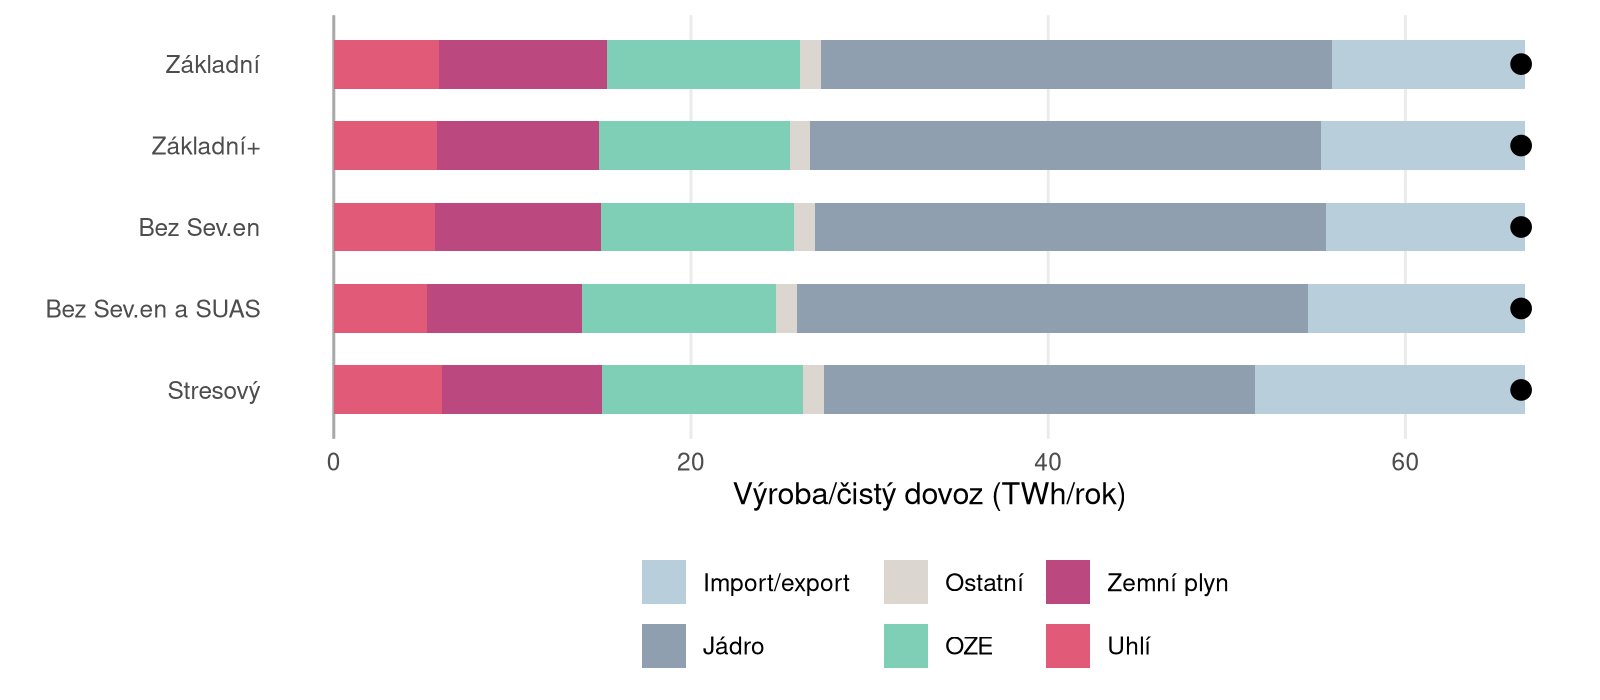

In [8]:
fig_width <- 8
fig_height <- 3.5
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_production |>
  ggplot(aes(production_TWh, fct_rev(name))) +
  geom_vline(xintercept = 0, colour = "darkgrey") +
  geom_col(
    aes(fill = fct_relevel(source_group, "NetImport", "Nuclear", "Other", "Renewables", "Gas")),
    width = .6
  ) +
  geom_point(
    aes(x = demand_TWh),
    data = df_import_totals |>
      filter(region == "CZ", stat == "load_TWh") |>
      select(name, region, demand_TWh = val),
    size = 3,
    fill = "black"
  ) +
  scale_fill_source() +
  labs(
    x = "Výroba/čistý dovoz (TWh/rok)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(save_svgs, df_production, "fig-1-production-by-source", fig_width, fig_height)


## Fig. 3.1: Coal capacity


In [9]:
df_coal_capacities_short <- df_coal_capacities |>
  select(name, coal_chp, coal_power) |>
  mutate(across(coal_chp:coal_power, ~ .x / coal_capacity_derating))

df_coal_capacities_short


name,coal_chp,coal_power
<fct>,<dbl>,<dbl>
Základní,3.221212,3.950000
Základní+,3.221212,3.950000
Bez Sev.en,2.818182,2.130303
Bez Sev.en a SUAS,2.453030,1.968182
Stresový,2.453030,1.968182


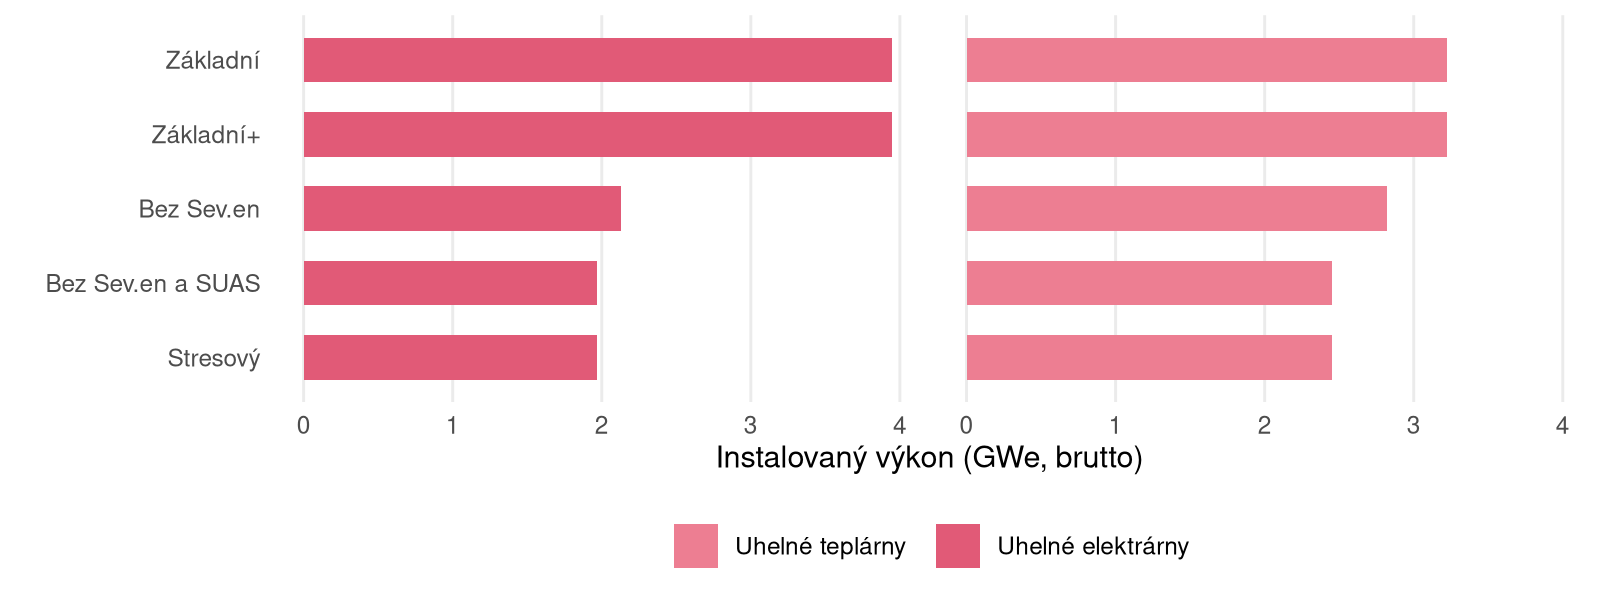

In [10]:
fig_width <- 8
fig_height <- 3
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_coal_capacities_short |>
  pivot_longer(!name, names_to = "category", values_to = "capacity") |>
  ggplot(aes(capacity, fct_rev(name))) +
  geom_col(aes(fill = category), width = .6) +
  scale_x_continuous(
    "Instalovaný výkon (GWe, brutto)",
    breaks = seq(0, 5)
  ) +
  scale_fill_coal_category() +
  facet_grid(cols = vars(category == "coal_chp")) +
  labs(y = "") +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line(),
    strip.text = element_blank()
  )

save_svg_data(save_svgs, df_coal_capacities_short, "fig-3.1-coal-installed-capacity", fig_width, fig_height)


## Fig. 3.2: Fossil production


In [11]:
df_production_fossil <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat == "production_TWh",
    str_detect(source, "^coal|^lig|^gas")
  ) |>
  summarise(
    val = mean(val),
    .by = c(name, region, source)
  ) |>
  mutate(
    source_group = case_when(
      str_detect(source, "gas_(eng_)?chp") ~ "gas_chp",
      str_detect(source, "^gas") ~ "gas_power",
      str_detect(source, "_bp$|_ex$") ~ "coal_chp",
      .default = "coal_power"
    )
  ) |>
  summarise(
    production_TWh = sum(val, na.rm = TRUE),
    .by = c(name, region, source_group)
  ) |>
  arrange(name, region, source_group) |>
  mutate(
    source_group = factor(
      source_group,
      levels = c("coal_power", "coal_chp", "gas_power", "gas_chp"),
      labels = c("Uhlí, elektrárny", "Uhlí, teplárny", "Zemní plyn, elektrárny", "Zemní plyn, teplárny")
    )
  )


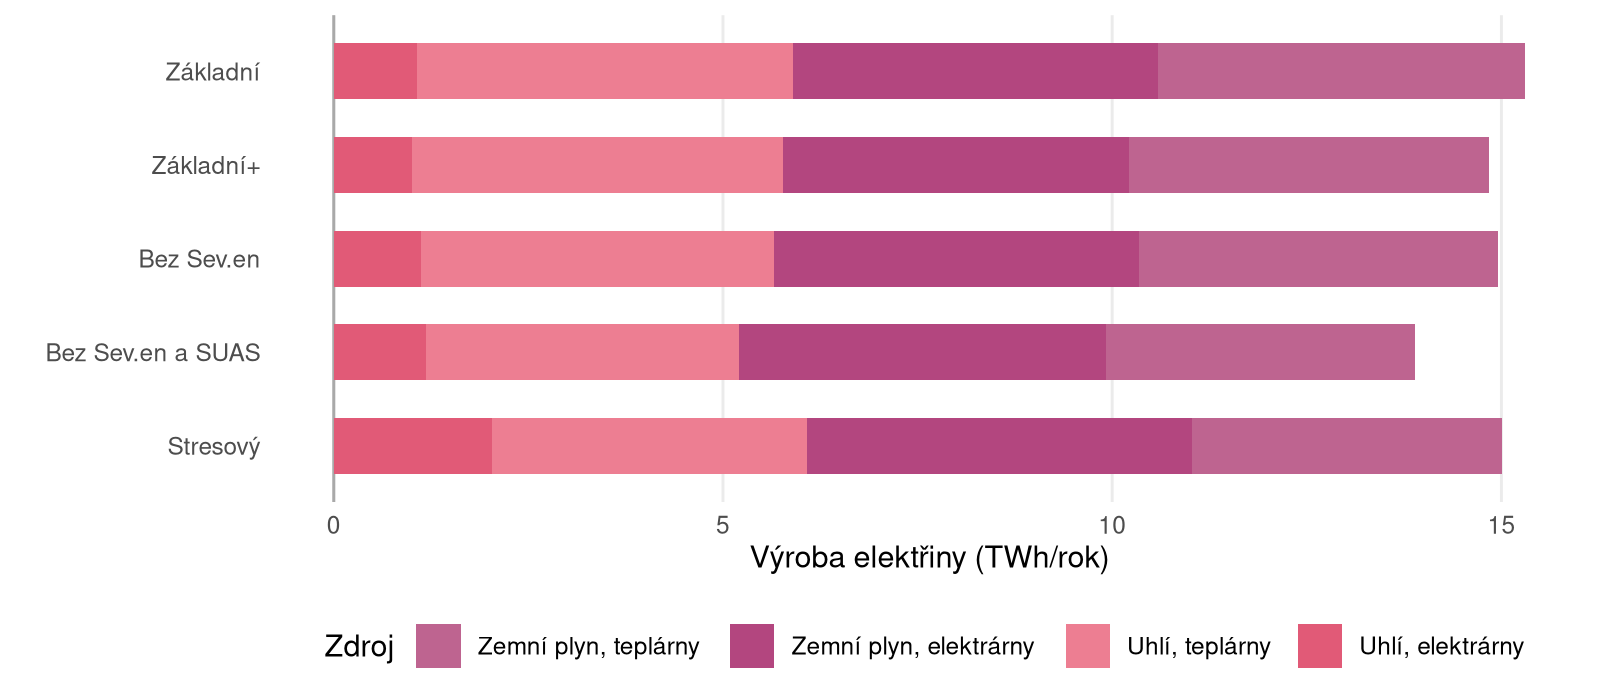

In [12]:
fig_width <- 8
fig_height <- 3.5
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_production_fossil |>
  ggplot(aes(production_TWh, fct_rev(name))) +
  geom_vline(xintercept = 0, colour = "darkgrey") +
  geom_col(
    aes(fill = fct_rev(source_group)),
    width = .6
  ) +
  scale_fill_manual(
    "Zdroj",
    values = c("#be6490", "#b3467f", "#ed7e92", "#e15a77")
  ) +
  labs(
    x = "Výroba elektřiny (TWh/rok)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(save_svgs, df_production_fossil, "fig-3.2-fossil-production", fig_width, fig_height)


### Subclaim: LOLE & EENS


In [13]:
df_lole <- df_all_years_stats |>
  filter(
    stat %in% c("production_hours", "production_TWh"),
    source == "eens"
  ) |>
  summarise(
    val = mean(val),
    .by = c(name, region, stat)
  ) |>
  pivot_wider(names_from = stat, values_from = val) |>
  transmute(
    name,
    region,
    eens_GWh = round(production_TWh * 1000, 2),
    lole_h = production_hours
  ) |>
  filter(lole_h > 0)

df_lole


name,region,eens_GWh,lole_h
<fct>,<chr>,<dbl>,<dbl>
Základní,LU,0.29,0.3333333
Základní,DE,1.57,0.5000000
Bez Sev.en,LU,0.29,0.3333333
Bez Sev.en,DE,1.57,0.5000000
Bez Sev.en a SUAS,DE,1.57,0.5000000
Bez Sev.en a SUAS,LU,0.29,0.3333333
Stresový,LU,26.88,27.6666667
Stresový,GB,33.44,7.3333333
Stresový,DE,216.22,22.3333333


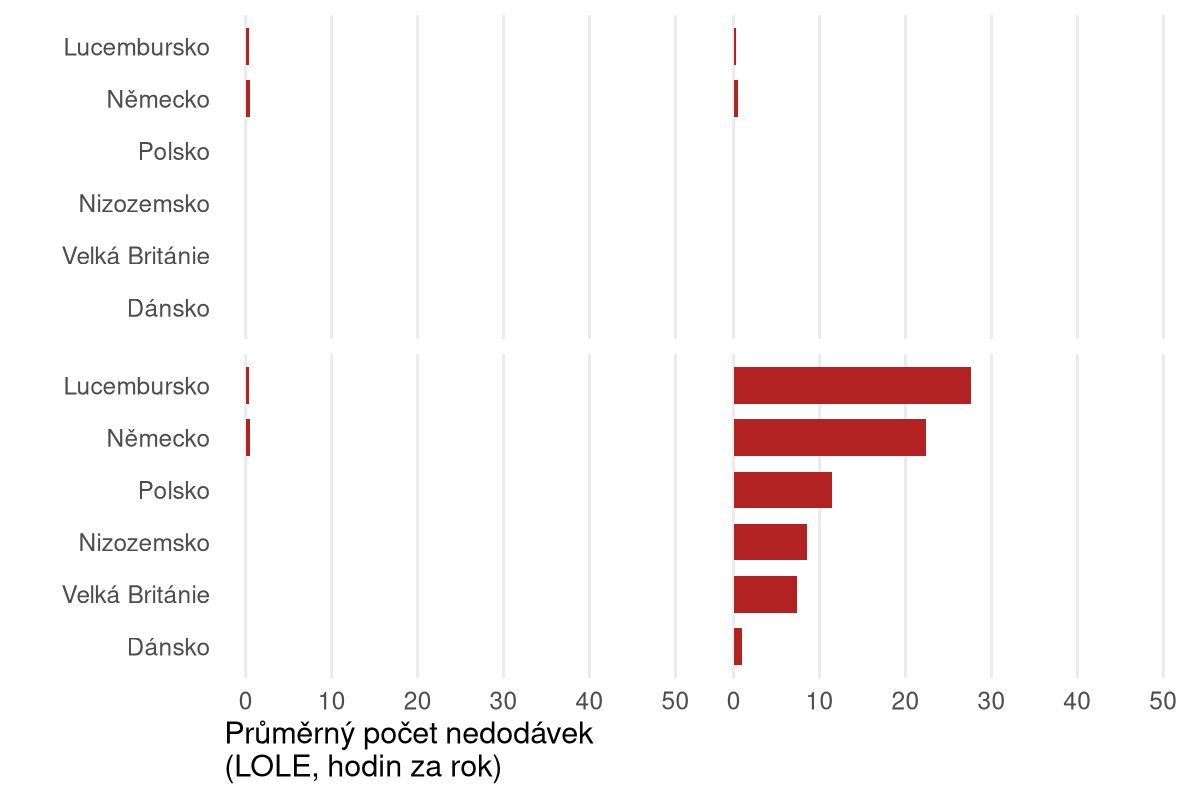

In [14]:
fig_width <- 6
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

if (nrow(df_lole) > 0) {
  df_lole |>
    mutate(
      country_name = region |>
        countrycode::countrycode(
          origin = "iso2c",
          destination = "cldr.name.cs",
          custom_match = c("GB" = "Velká Británie"),
          nomatch = NULL
        ) |>
        fct_reorder(lole_h, max),
    ) |>
    filter(lole_h >= .1) |>
    ggplot(aes(lole_h, country_name)) +
    geom_col(
      fill = "firebrick",
      width = .7
    ) +
    coord_cartesian(xlim = c(0, 50), clip = "off") +
    facet_wrap(vars(name)) +
    labs(
      x = "Průměrný počet nedodávek \n(LOLE, hodin za rok)",
      y = ""
    ) +
    theme(
      axis.title.x = element_text(hjust = 0),
      panel.grid.major.x = element_line(),
      panel.grid.major.y = element_blank(),
      strip.text = element_blank()
    )
}


## Fig. 3.3: Import/export by neighbour


In [15]:
df_daily_imports_all <- str_glue("{output_dir}/coaldown2+weather-WS??/*/CZ.csv") |>
  Sys.glob() |>
  map(
    ~ read_csv(.x) |>
      select(Date, starts_with("Import_") | starts_with("Export_")) |>
      group_by(Date = as_date(Date)) |>
      summarise(across(everything(), sum)) |>
      mutate(
        name = str_extract(.x, "(?<=/)[^/]+(?=/\\w+\\.csv)"),
        weather = str_extract(.x, "WS\\d\\d"),
        .before = 1
      )
  ) |>
  list_rbind() |>
  pivot_longer(
    !name:Date,
    names_sep = "_",
    names_to = c("direction", "neighbour"),
    values_to = "value"
  ) |>
  mutate(value = value / 1e6) |>
  pivot_wider(names_from = direction, values_from = value) |>
  fix_scenario_names()

df_weekly_imports_all <- df_daily_imports_all |>
  group_by(name, weather, neighbour, week = isoweek(Date)) |>
  summarise(across(!Date, sum), .groups = "drop")

df_weekly_imports_year <- df_weekly_imports_all |>
  filter(weather == mainline_weather_year)

df_weekly_imports <- df_weekly_imports_all |>
  summarise(
    Import = mean(Import),
    Export = mean(Export),
    .by = c(name, week, neighbour)
  )


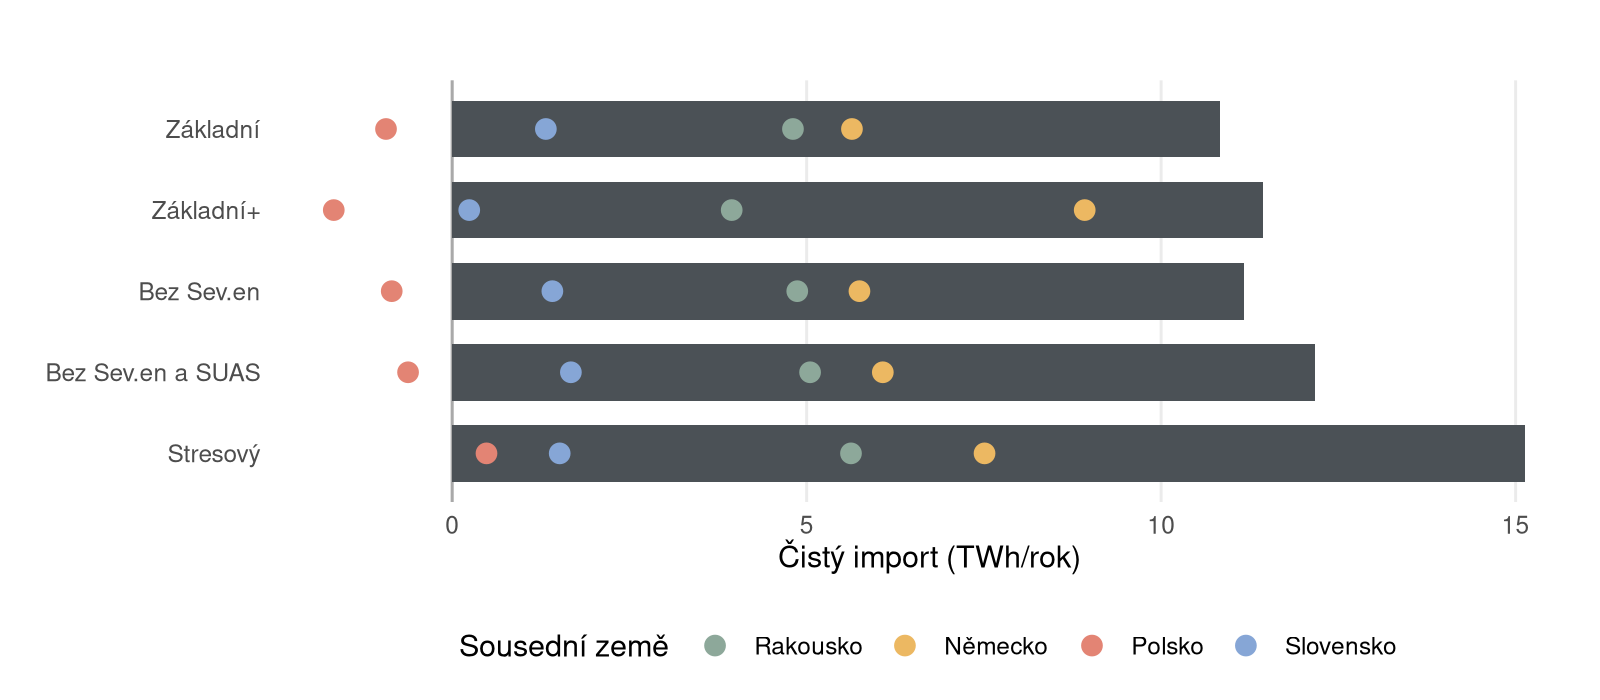

In [16]:
fig_width <- 8
fig_height <- 3.5
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_weekly_imports |>
  summarise(across(Import:Export, sum), .by = c(name, neighbour)) |>
  ggplot(aes(x = Import - Export, y = fct_rev(name))) +
  geom_vline(xintercept = 0, colour = "darkgrey") +
  stat_summary(
    aes(group = name),
    fun = sum,
    geom = "col",
    fill = "#4b5156",
    width = .7
  ) +
  geom_point(aes(colour = neighbour), size = 3) +
  scale_colour_region() +
  labs(
    title = "",
    x = "Čistý import (TWh/rok)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(
  save_svgs,
  df_weekly_imports |>
    summarise(across(Import:Export, sum), .by = c(name, neighbour)) |>
    rename(ExportTWh = Export, ImportTWh = Import),
  "fig-3.3-cross-border-balance",
  fig_width,
  fig_height
)


## Fig. 3.3a: Weekly cross-border flows


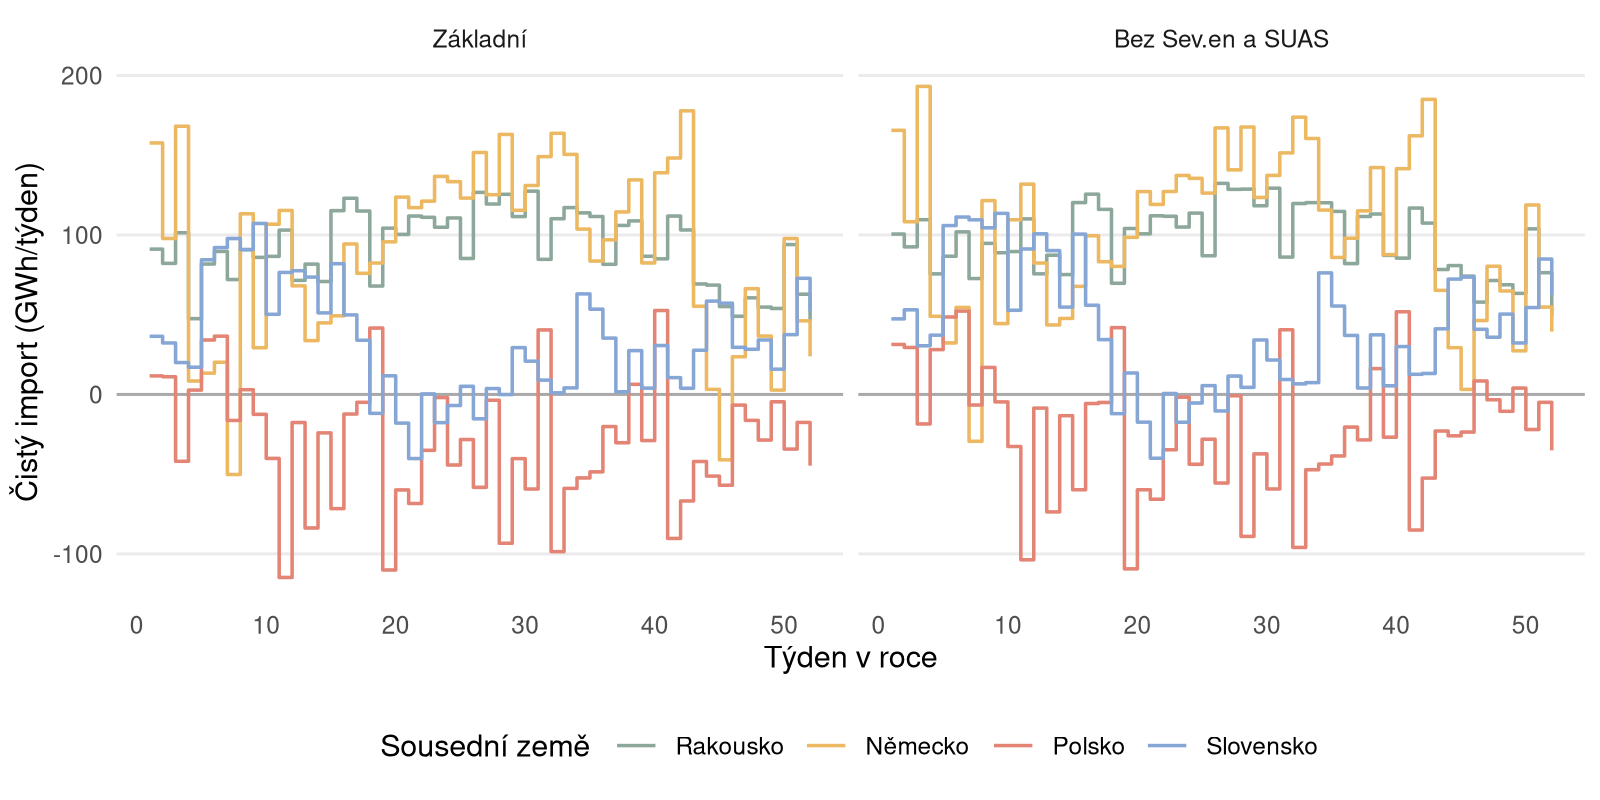

In [17]:
fig_width <- 8
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_weekly_imports_year |>
  filter(name %in% c("Základní", "Bez Sev.en a SUAS")) |>
  ggplot(aes(x = week, y = 1000 * (Import - Export))) +
  geom_hline(yintercept = 0, colour = "darkgrey") +
  geom_step(aes(colour = neighbour), linewidth = .6) +
  scale_colour_region() +
  facet_wrap(vars(name)) +
  labs(
    x = "Týden v roce",
    y = "Čistý import (GWh/týden)",
  ) +
  theme(
    legend.position = "bottom"
  )

save_svg_data(
  save_svgs,
  df_weekly_imports_year |>
    rename(ExportTWh = Export, ImportTWh = Import),
  "fig-3.3a-cross-border-weekly-flows",
  fig_width,
  fig_height
)


## Fig. 3.3b: Annual net imports


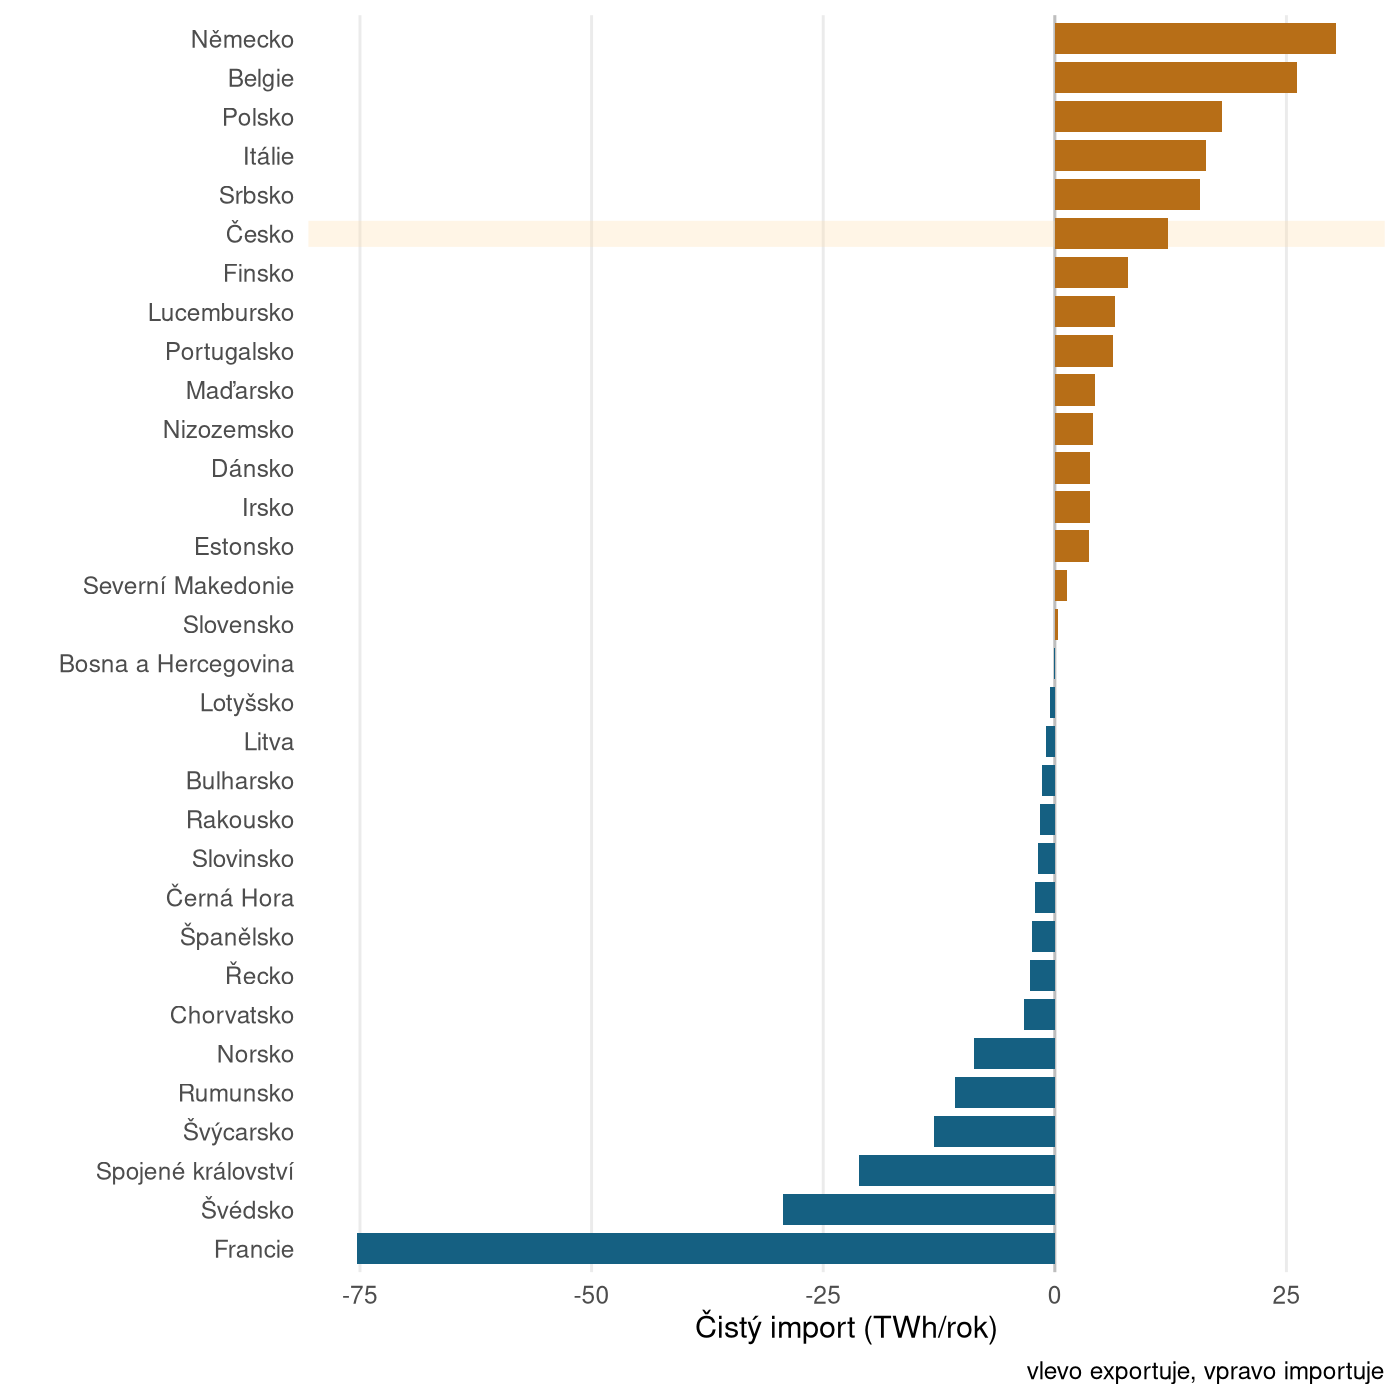

In [18]:
fig_width <- 7
fig_height <- 7
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_net_imports_across_europe <- df_import_totals |>
  pivot_wider(names_from = stat, values_from = val) |>
  filter(name == "Bez Sev.en a SUAS") |>
  select(name, country_name, net_import_TWh, demand_TWh = load_TWh) |>
  mutate(
    country_name = fct_reorder(country_name, net_import_TWh)
  )

df_net_imports_across_europe |>
  ggplot(aes(net_import_TWh, country_name)) +
  geom_vline(xintercept = 0, colour = "grey") +
  geom_hline(yintercept = "Česko", linewidth = 4.4, colour = "navajowhite", alpha = .3) +
  geom_col(aes(fill = net_import_TWh > 0), width = .8) +
  scale_fill_manual(values = c("#156082", "#b76e17"), guide = "none") +
  labs(
    x = "Čistý import (TWh/rok)",
    y = "",
    caption = "vlevo exportuje, vpravo importuje"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )

save_svg_data(
  save_svgs,
  df_net_imports_across_europe,
  "fig-3.3b-net-imports-across-europe",
  fig_width,
  fig_height
)


## Fig. 3.3e: Relative annual net imports


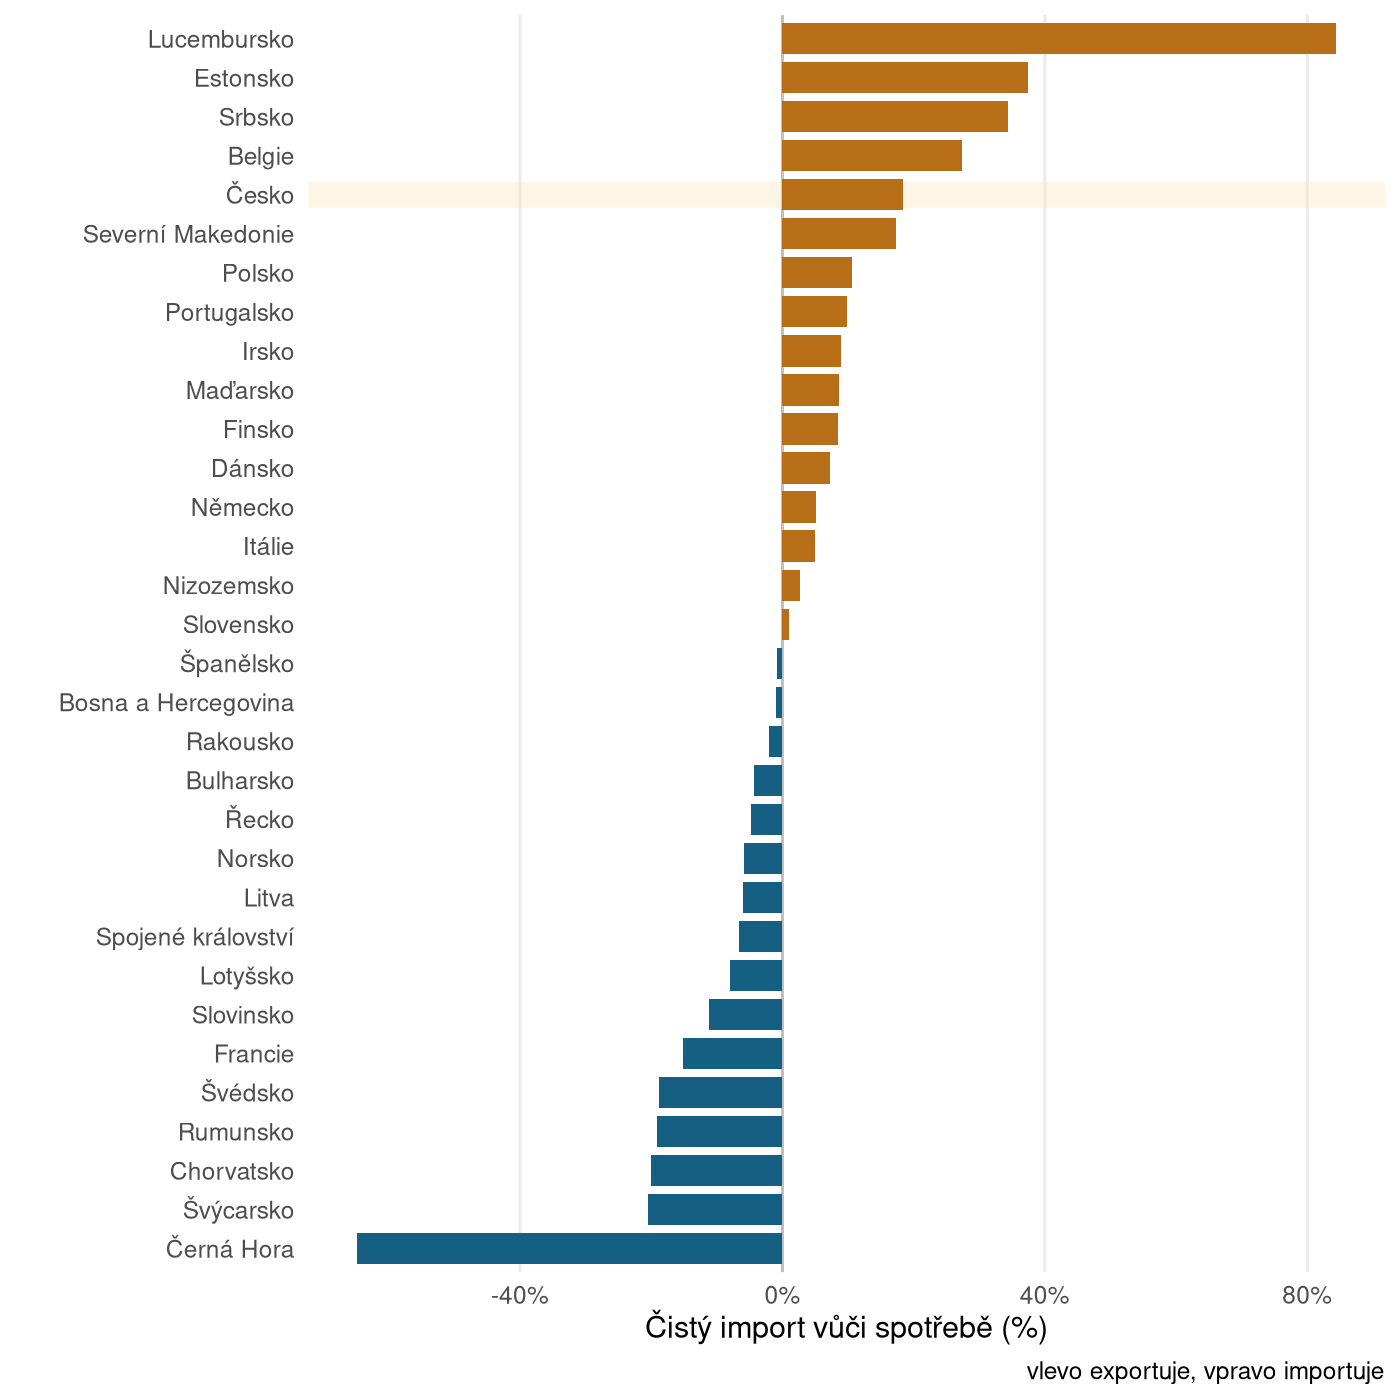

In [19]:
fig_width <- 7
fig_height <- 7
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_net_imports_across_europe |>
  mutate(relative_net_import = net_import_TWh / demand_TWh) |>
  ggplot(aes(relative_net_import, fct_reorder(country_name, relative_net_import))) +
  geom_vline(xintercept = 0, colour = "grey") +
  geom_hline(yintercept = "Česko", linewidth = 4.4, colour = "navajowhite", alpha = .3) +
  geom_col(aes(fill = net_import_TWh > 0), width = .8) +
  scale_x_continuous(labels = scales::label_percent()) +
  scale_fill_manual(values = c("#156082", "#b76e17"), guide = "none") +
  labs(
    x = "Čistý import vůči spotřebě (%)",
    y = "",
    caption = "vlevo exportuje, vpravo importuje"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )

save_svg_data(
  save_svgs,
  df_net_imports_across_europe,
  "fig-3.3e-net-imports-across-europe-relative",
  fig_width,
  fig_height
)


## Identifying a Dunkelflaute episode


Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


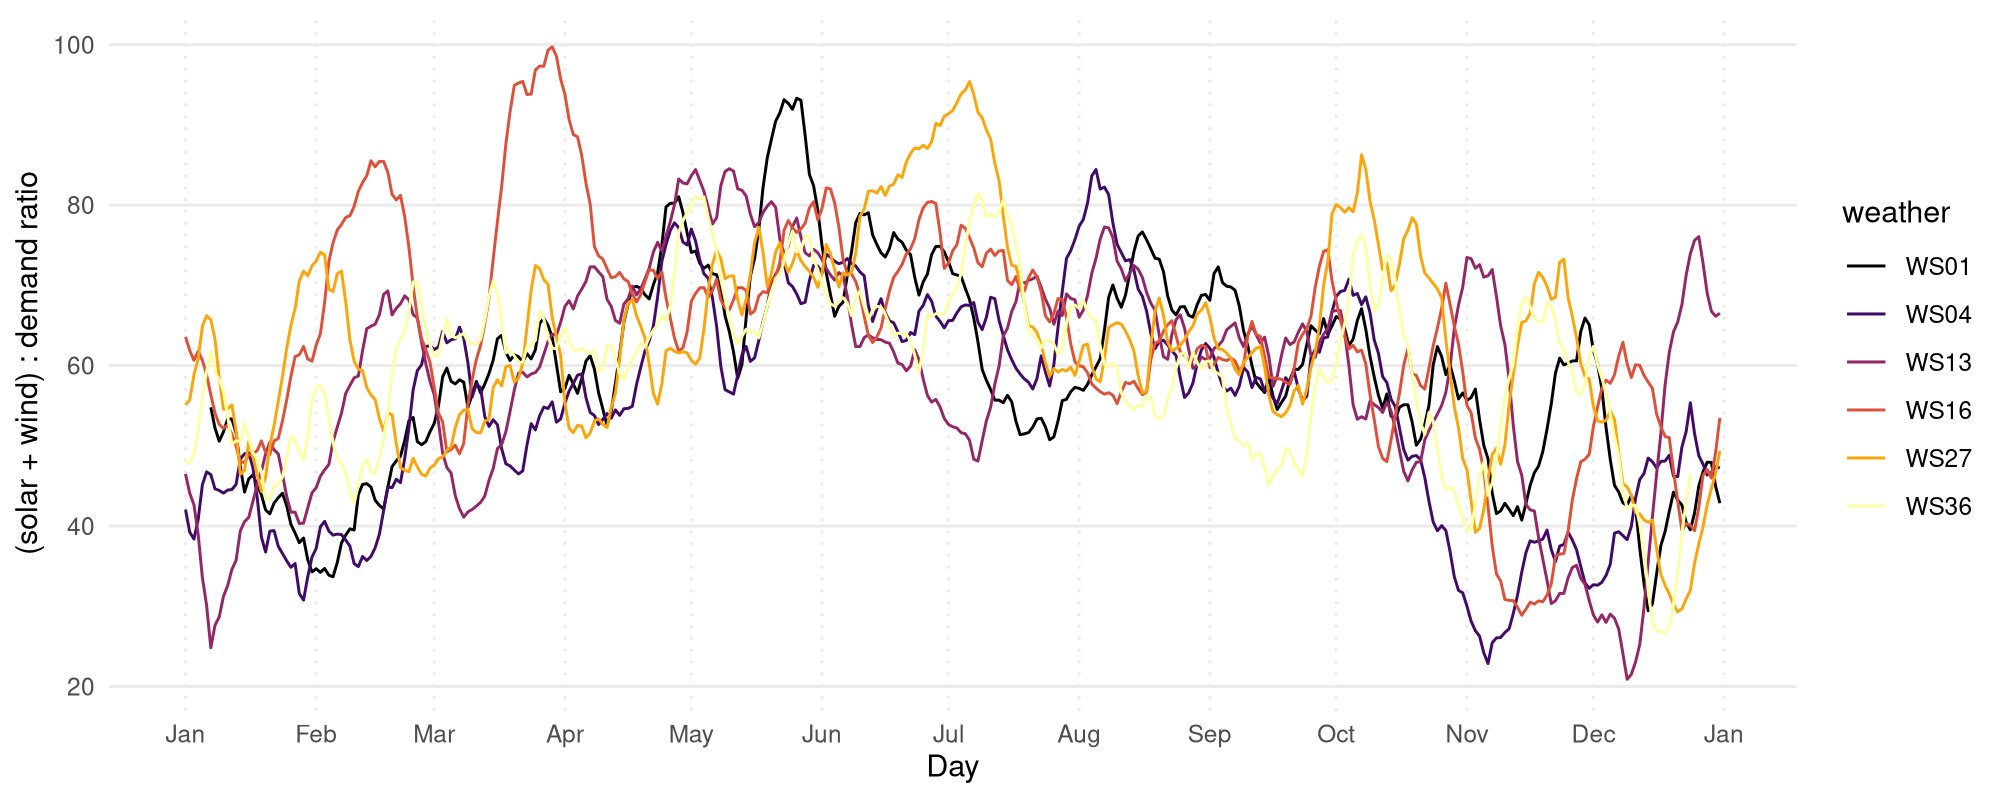

In [20]:
fig_width <- 10
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

# Visualize 14-day rolling mean ratio of solar + wind to load in
# the Central European region in order to indentify Dunkelflaute periods.
df_hourlies |>
  # filter(region == "CZ", name == "Základní") |>
  filter(region %in% c("CZ", "DE", "DK", "PL", "SK", "AT"), name == "Základní") |>
  group_by(weather, Day = as_date(Date)) |>
  summarise(
    Demand = sum(Load) / 1e3,
    SW = sum(Solar + Wind) / 1e3,
    .groups = "drop"
  ) |>
  mutate(
    SWFraction = SW / Demand
  ) |>
  ggplot(aes(Day, 100 * zoo::rollmean(SWFraction, 14, na.pad = T))) +
  geom_line(aes(colour = weather)) +
  scale_x_datetime(date_breaks = "1 month", date_labels = "%b") +
  scale_y_continuous("(solar + wind) : demand ratio") +
  scale_colour_viridis_d(option = "B") +
  theme(
    panel.grid.major.x = element_line(linetype = "dotted")
  )


Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


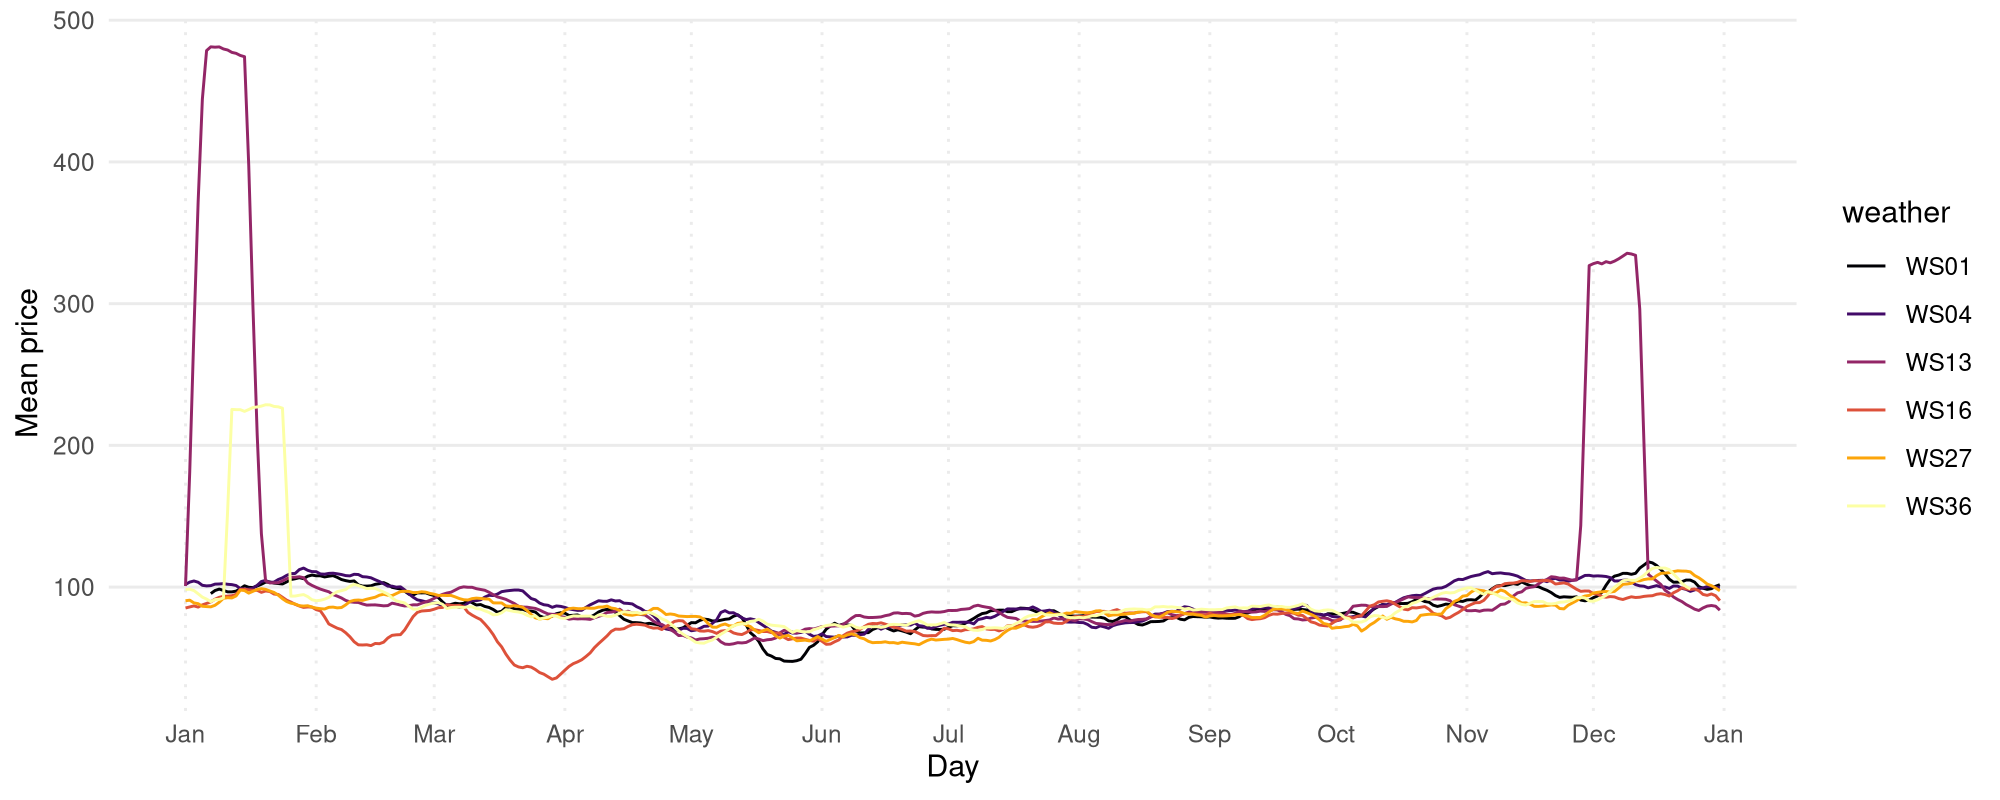

In [43]:
fig_width <- 10
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

# Visualize 14-day rolling mean price.
df_hourlies |>
  # filter(region == "CZ", name == "Základní") |>
  filter(region %in% c("CZ", "DE", "DK", "PL", "SK", "AT"), name == "Základní") |>
  group_by(weather, Day = as_date(Date), region) |>
  summarise(
    Demand = sum(Load),
    AvgPrice = weighted.mean(Price, Load),
    .groups = "drop_last"
  ) |>
  summarise(
    AvgPrice = weighted.mean(AvgPrice, Demand),
    .groups = "drop"
  ) |>
  ggplot(aes(Day, zoo::rollmean(AvgPrice, 14, na.pad = T))) +
  geom_line(aes(colour = weather)) +
  scale_x_datetime(date_breaks = "1 month", date_labels = "%b") +
  scale_y_continuous("Mean price") +
  scale_colour_viridis_d(option = "B") +
  theme(
    panel.grid.major.x = element_line(linetype = "dotted")
  )


## Fig. 3.5: Daily cross-border flows during a Dunkelflaute


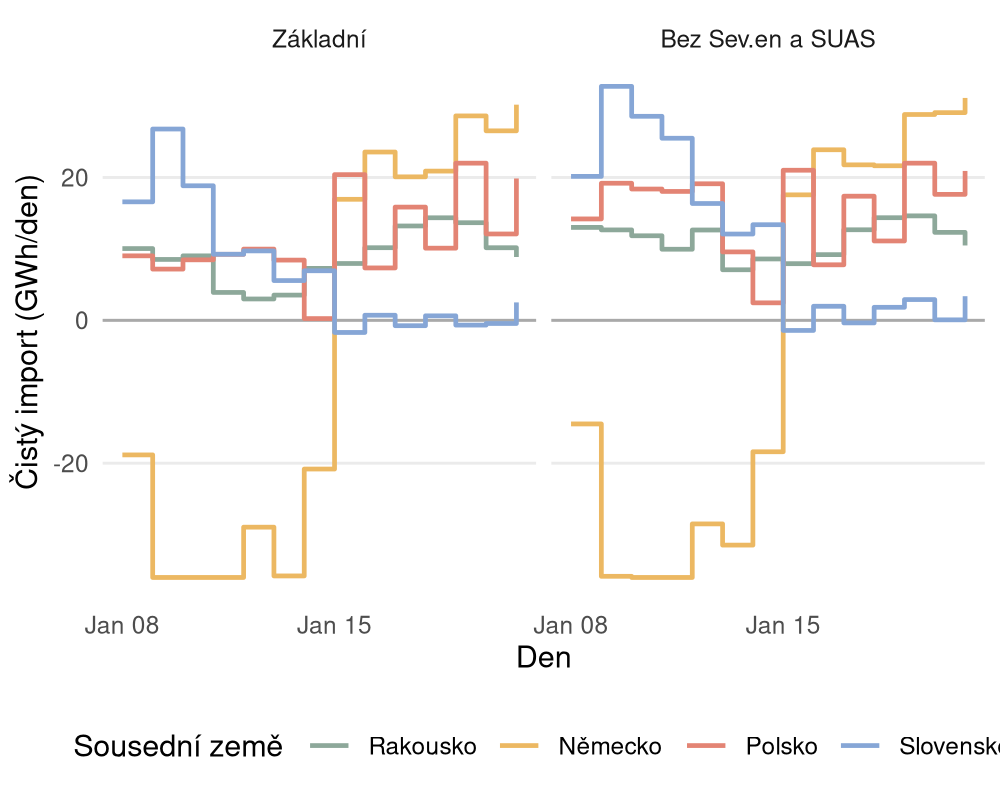

In [ ]:
fig_width <- 5
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_daily_imports_dunkelflaute <- df_daily_imports_all |>
  filter(
    weather == dunkelflaute_weather,
    dunkelflaute_period[1] <= Date,
    Date < dunkelflaute_period[2]
  ) |>
  mutate(
    ExportGWh = 1000 * Export,
    ImportGWh = 1000 * Import,
    .keep = "unused"
  )

df_daily_imports_dunkelflaute |>
  filter(name %in% c("Základní", "Bez Sev.en a SUAS")) |>
  ggplot(aes(x = Date, y = ImportGWh - ExportGWh)) +
  geom_hline(yintercept = 0, colour = "darkgrey") +
  geom_step(aes(colour = neighbour), linewidth = .8) +
  scale_colour_region() +
  facet_wrap(vars(name)) +
  labs(
    x = "Den",
    y = "Čistý import (GWh/den)",
  ) +
  theme(
    legend.position = "bottom"
  )

save_svg_data(
  save_svgs,
  df_daily_imports_dunkelflaute,
  "fig-3.5-cross-border-daily-flows-dunkelflaute",
  fig_width,
  fig_height
)


## Fig. 3.3c: Net imports during a Dunkelflaute


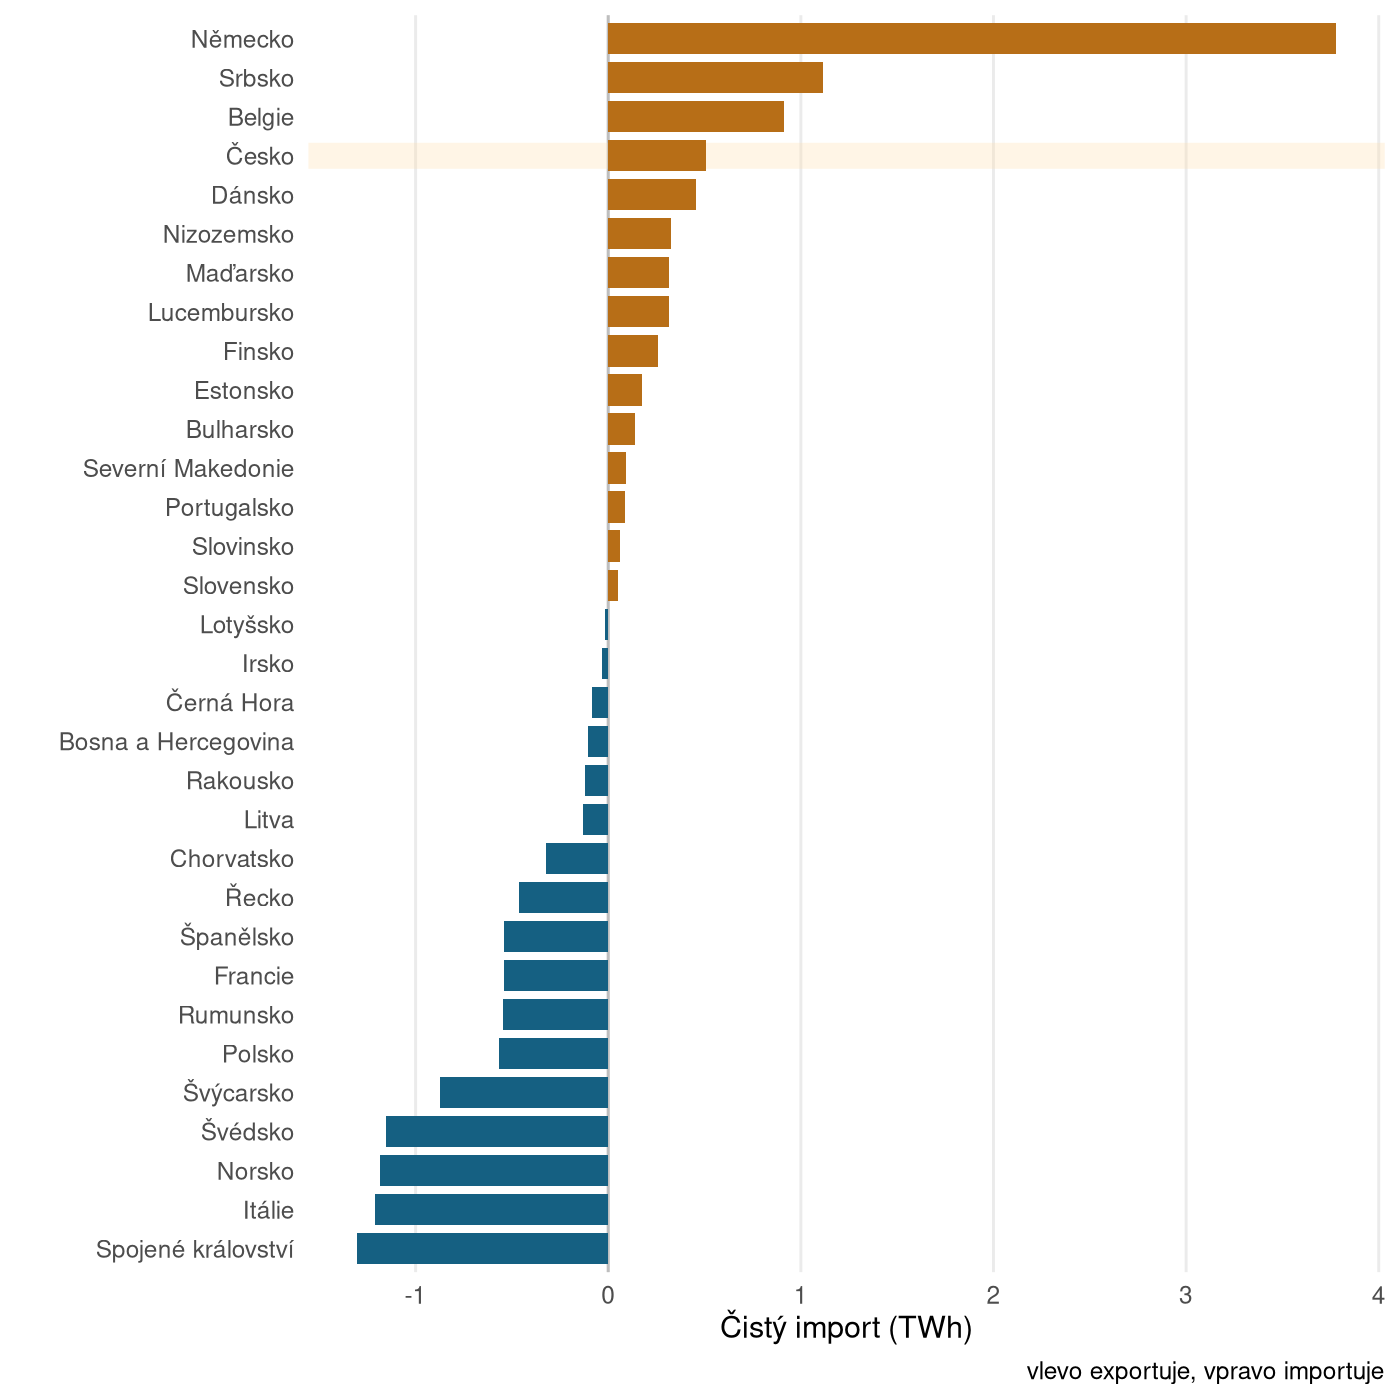

In [46]:
fig_width <- 7
fig_height <- 7
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_net_imports_dunkelflaute <- df_hourlies |>
  filter(
    name == "Bez Sev.en a SUAS",
    weather == dunkelflaute_weather,
    dunkelflaute_period[1] <= Date,
    Date < dunkelflaute_period[2]
  ) |>
  summarise(
    net_import_TWh = sum(Import - Export) / 1e6,
    demand_TWh = sum(Load) / 1e6,
    .by = region
  ) |>
  mutate(
    country_name = countrycode::countrycode(
      region,
      origin = "iso2c",
      destination = "cldr.name.cs",
      nomatch = NULL
    ) |> fct_reorder(net_import_TWh)
  )

df_net_imports_dunkelflaute |>
  ggplot(aes(net_import_TWh, country_name)) +
  geom_vline(xintercept = 0, colour = "grey") +
  geom_hline(yintercept = "Česko", linewidth = 4.4, colour = "navajowhite", alpha = .3) +
  geom_col(aes(fill = net_import_TWh > 0), width = .8) +
  scale_fill_manual(values = c("#156082", "#b76e17"), guide = "none") +
  labs(
    x = "Čistý import (TWh)",
    y = "",
    caption = "vlevo exportuje, vpravo importuje"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )

save_svg_data(
  save_svgs,
  df_net_imports_dunkelflaute,
  "fig-3.3c-net-imports-across-europe-dunkelflaute",
  fig_width,
  fig_height
)


## Fig. 3.3d: Relative net imports during a Dunkelflaute


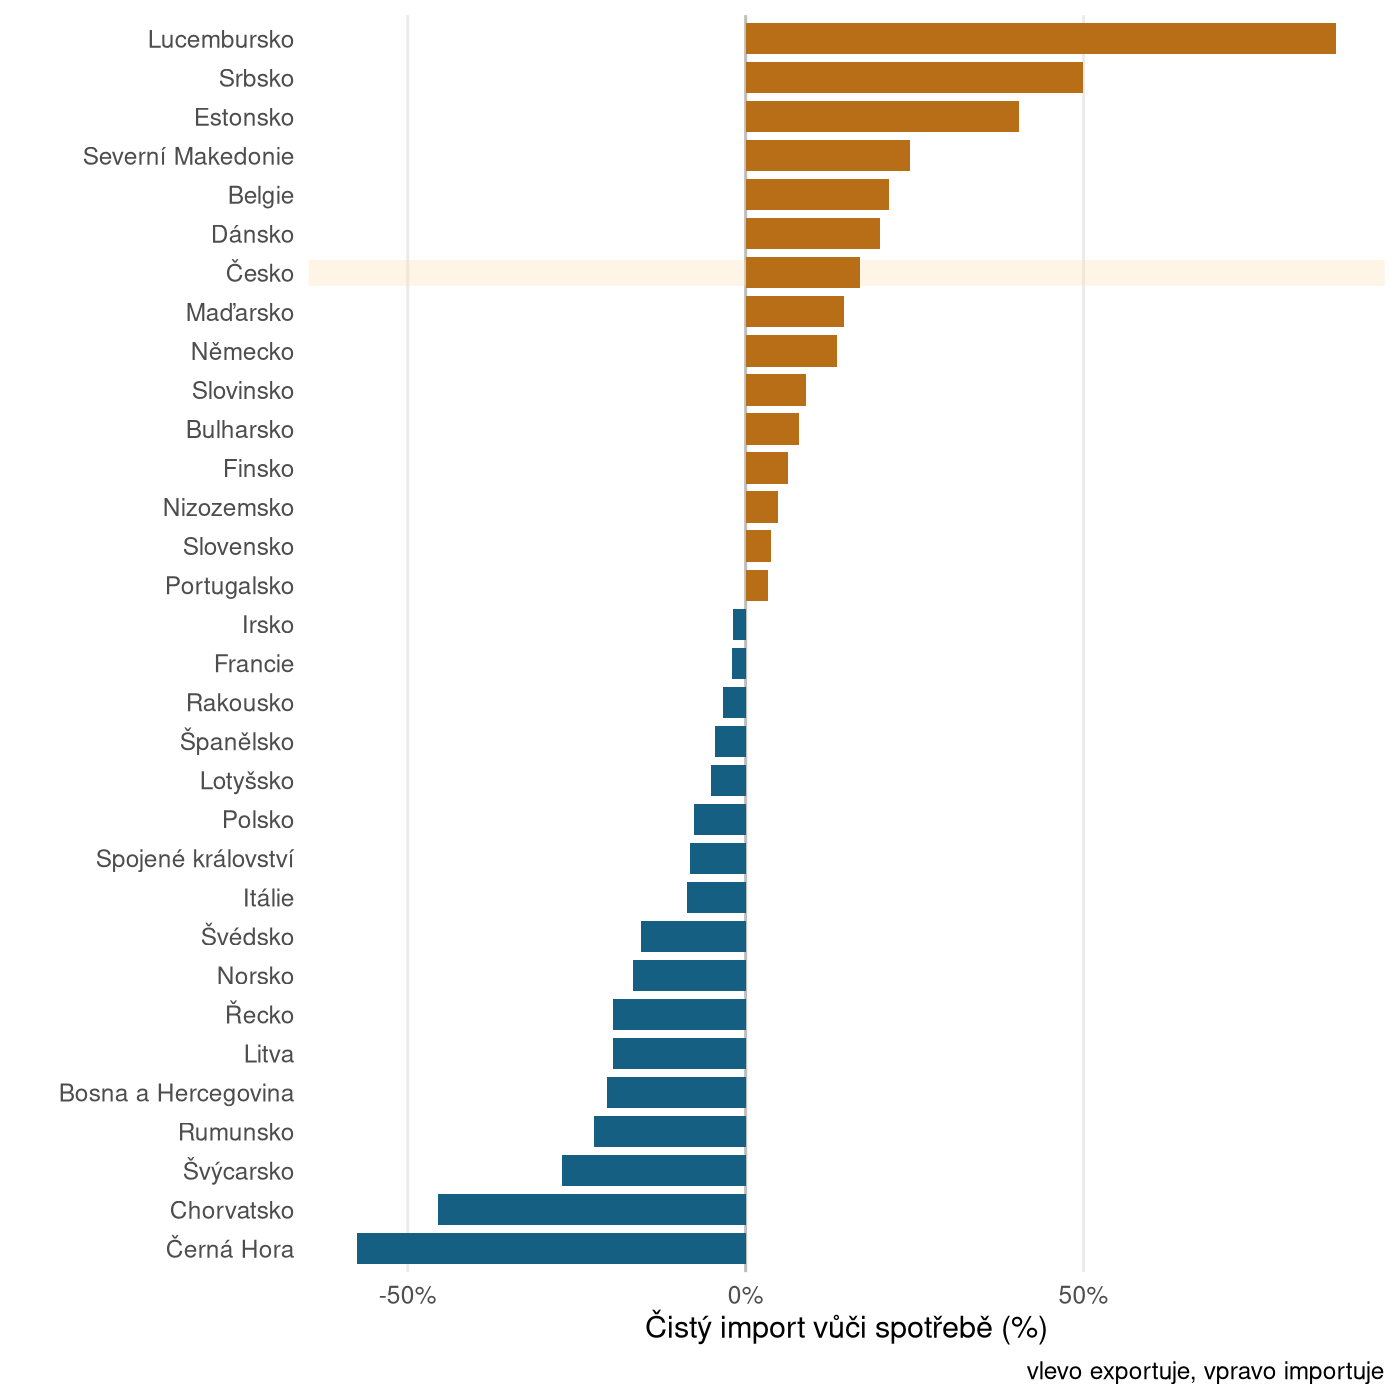

In [47]:
fig_width <- 7
fig_height <- 7
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_net_imports_dunkelflaute |>
  mutate(relative_net_import = net_import_TWh / demand_TWh) |>
  ggplot(aes(relative_net_import, fct_reorder(country_name, relative_net_import))) +
  geom_vline(xintercept = 0, colour = "grey") +
  geom_hline(yintercept = "Česko", linewidth = 4.4, colour = "navajowhite", alpha = .3) +
  geom_col(aes(fill = net_import_TWh > 0), width = .8) +
  scale_x_continuous(labels = scales::label_percent()) +
  scale_fill_manual(values = c("#156082", "#b76e17"), guide = "none") +
  labs(
    x = "Čistý import vůči spotřebě (%)",
    y = "",
    caption = "vlevo exportuje, vpravo importuje"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )

save_svg_data(
  save_svgs,
  df_net_imports_dunkelflaute,
  "fig-3.3d-net-imports-across-europe-dunkelflaute-relative",
  fig_width,
  fig_height
)


## Fig. 3.4: Power sector emissions


In [25]:
df_emissions <- df_all_years_stats |>
  filter(
    region == "CZ",
    stat == "emissions_MtCO2" | stat == "production_TWh"
  ) |>
  summarise(
    val = mean(val),
    .by = c(name, stat, source)
  ) |>
  pivot_wider(names_from = stat, values_from = val) |>
  mutate(
    emissions_MtCO2 = case_match(
      source,
      "lig_bp" ~ 1 * .4 / .2 * production_TWh,
      "lig_ex" ~ 1 * production_TWh,
      "coal_bp" ~ .846 * .4 / .2 * production_TWh,
      "coal_ex" ~ .846 * production_TWh,
      "gas_chp" ~ .22 / .56 * production_TWh,
      "gas_eng_chp" ~ .22 / .4 * production_TWh,
      .default = emissions_MtCO2
    ),
    source = case_when(
      str_detect(source, "^coal_(bp|ex)|^lig_(bp|ex)") ~ "Coal CHP",
      str_detect(source, "^coal|^lig") ~ "Coal power",
      str_detect(source, "^gas") ~ "Gas"
    )
  ) |>
  filter(!is.na(source)) |>
  summarise(
    emissions_MtCO2 = sum(emissions_MtCO2),
    .by = c(name, source)
  )

df_emissions |>
  pivot_wider(names_from = source, values_from = emissions_MtCO2) |>
  mutate(
    Total = `Coal CHP` + `Coal power` + Gas,
    across(where(is.numeric), ~ round(.x, 2))
  )


name,Gas,Coal power,Coal CHP,Total
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,3.94,1.03,6.50,11.47
Základní+,3.81,0.98,6.43,11.22
Bez Sev.en,3.90,1.08,6.18,11.16
Bez Sev.en a SUAS,3.66,1.13,5.63,10.42
Stresový,3.76,1.97,5.65,11.38


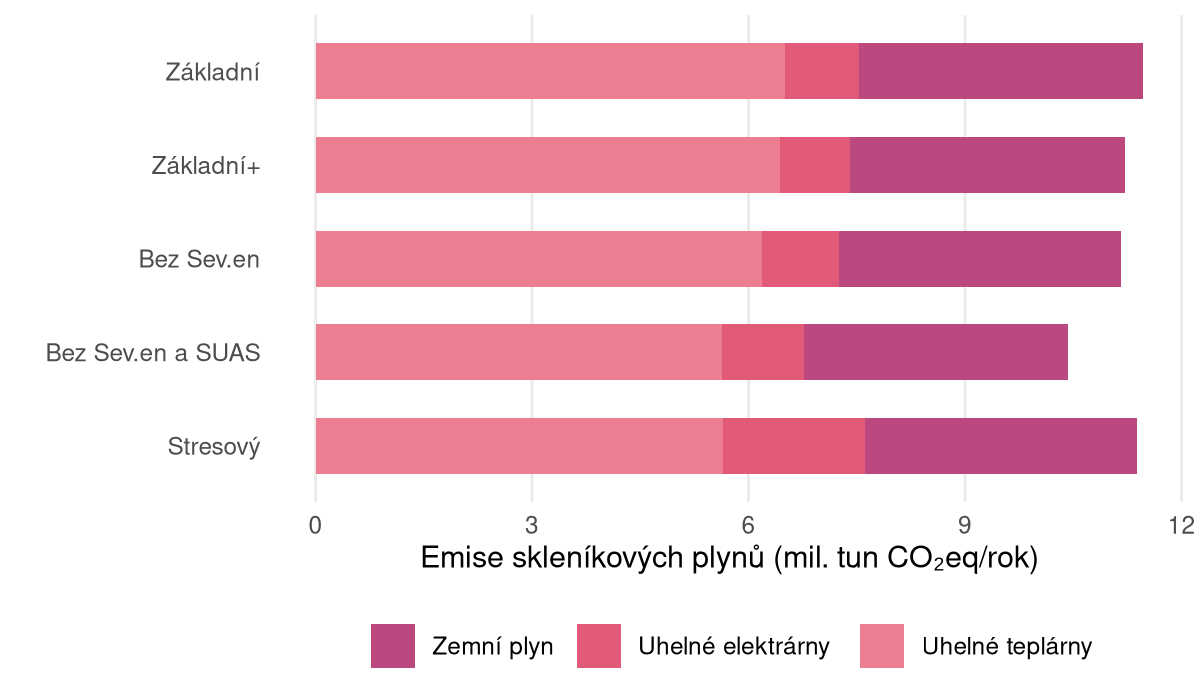

In [26]:
fig_width <- 6
fig_height <- 3.5
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_emissions |>
  ggplot(aes(emissions_MtCO2, fct_rev(name))) +
  geom_col(aes(fill = fct_rev(source)), width = .6) +
  scale_fill_source() +
  labs(
    x = "Emise skleníkových plynů (mil. tun CO₂eq/rok)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(save_svgs, df_emissions, "fig-3.4-power-ghg-emissions", fig_width, fig_height)


## Fig. 4.5: Average price comparison


In [27]:
df_annual_prices <- df_hourlies |>
  summarise(
    Price = weighted.mean(Price, Load),
    Demand = sum(Load) / 1e6,
    .by = c(name, region, weather)
  ) |>
  summarise(
    Price = mean(Price),
    Demand = mean(Demand),
    .by = c(name, region)
  )

df_annual_prices |>
  filter(region %in% c("CZ", "DE", "PL")) |>
  select(!Demand) |>
  pivot_wider(names_from = region, values_from = Price) |>
  mutate(
    CZ_DE_Diff = CZ - DE,
    across(where(is.numeric), ~ round(.x, 1))
  )


name,CZ,DE,PL,CZ_DE_Diff
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Základní,91.3,91.6,94.9,-0.3
Základní+,89.1,89.6,94.6,-0.6
Bez Sev.en,91.5,91.7,95.0,-0.1
Bez Sev.en a SUAS,93.4,91.7,96.4,1.6
Stresový,128.6,128.4,128.3,0.2


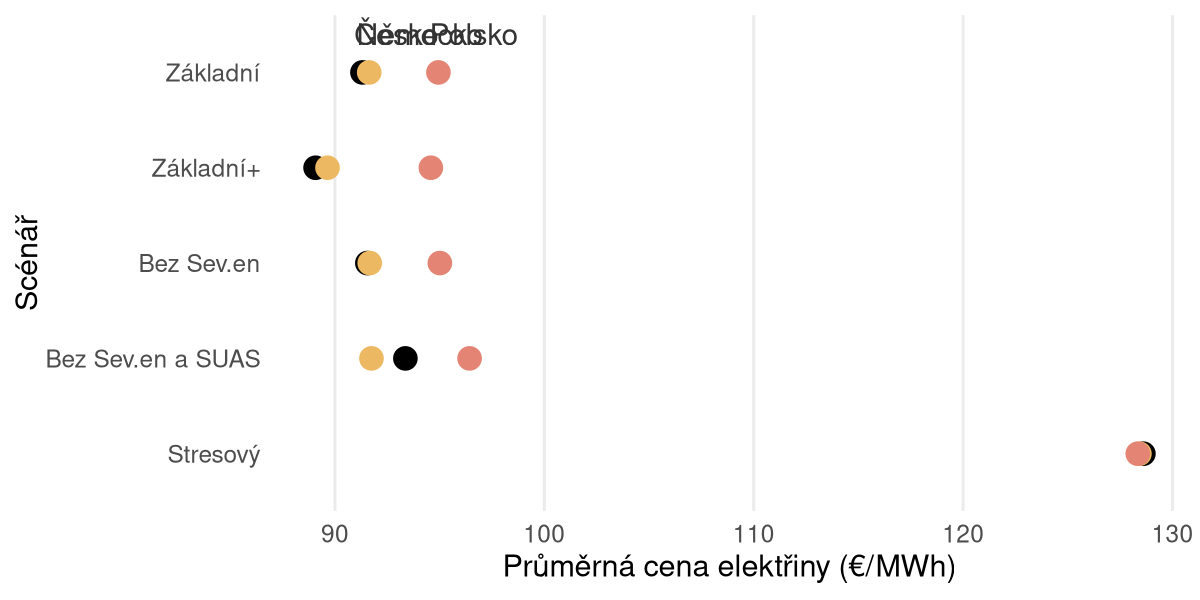

In [28]:
fig_width <- 6
fig_height <- 3
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_annual_prices |>
  filter(
    region %in% c("CZ", "DE", "PL")
  ) |>
  ggplot(aes(Price, fct_rev(name))) +
  geom_point(aes(colour = region), size = 3.5) +
  geom_text(
    aes(label = neighbour_labels[region]),
    data = ~ filter(.x, name == "Základní"),
    colour = "grey20",
    size = 3.8,
    nudge_y = .4,
    hjust = .1
  ) +
  scale_colour_region(guide = "none") +
  labs(
    x = "Průměrná cena elektřiny (€/MWh)",
    y = "Scénář"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )

save_svg_data(
  save_svgs,
  filter(df_annual_prices, region %in% c("CZ", "DE", "PL")),
  "fig-4.5-average-annual-prices",
  fig_width,
  fig_height
)


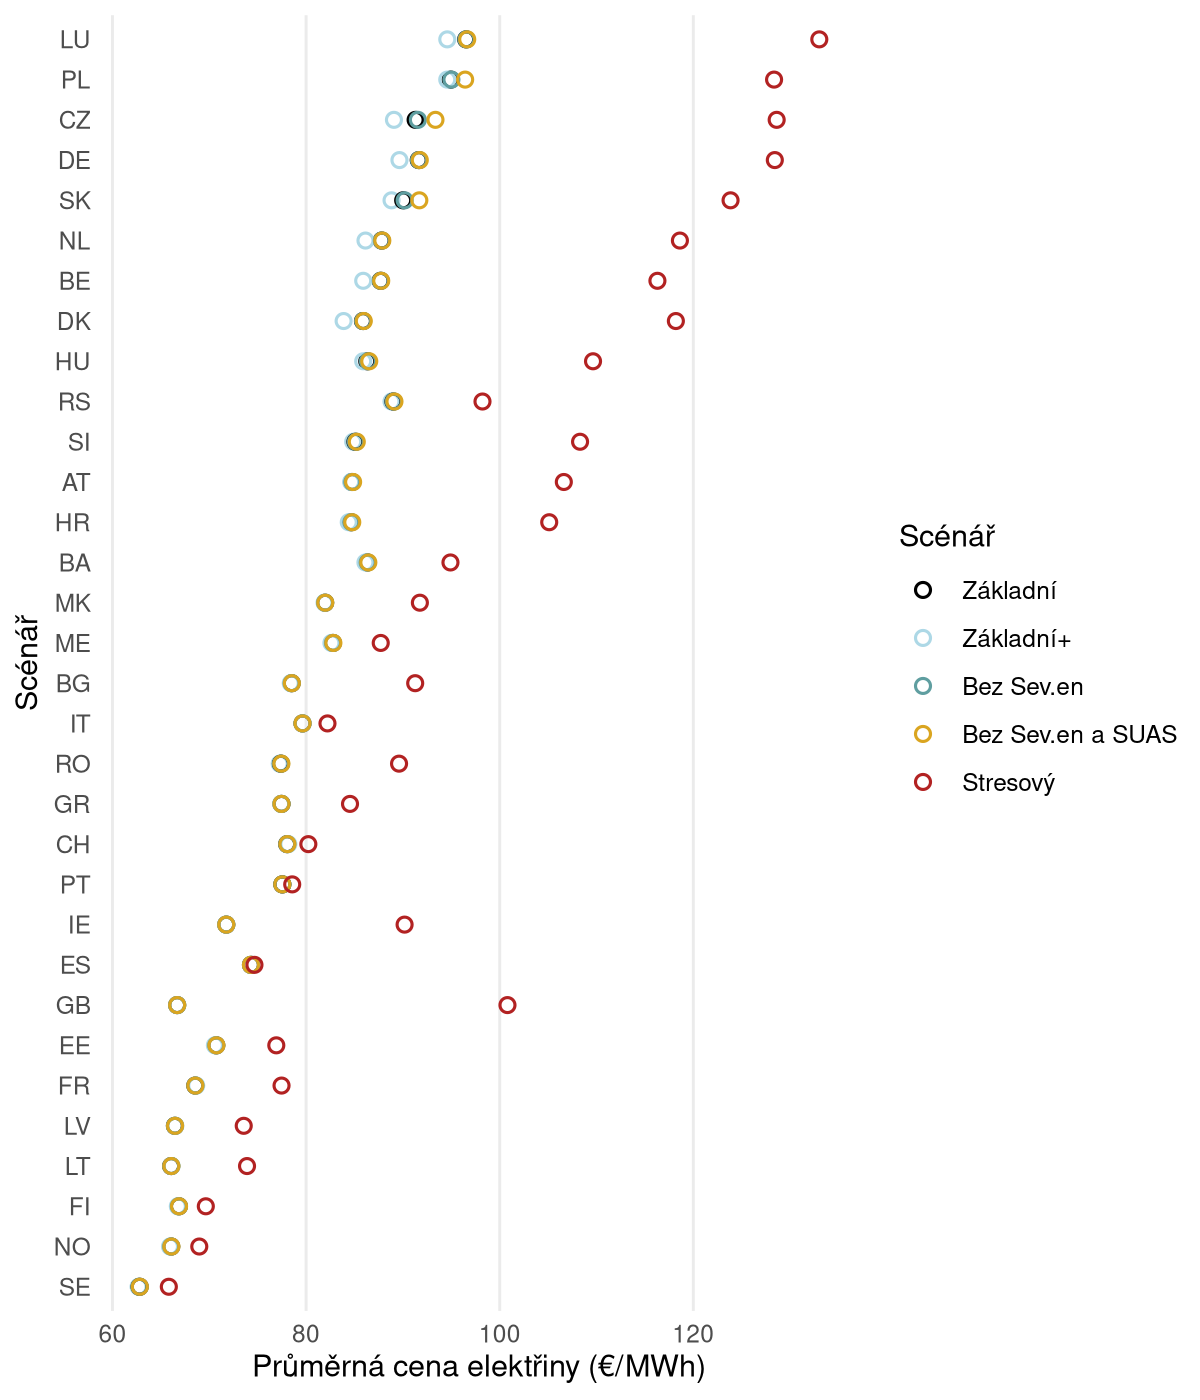

In [29]:
fig_width <- 6
fig_height <- 7
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_annual_prices |>
  ggplot(aes(Price, fct_reorder(region, Price, mean))) +
  geom_point(aes(colour = name), shape = 1, size = 2, stroke = .8) +
  scale_colour_manual(
    "Scénář",
    values = c("black", "lightblue", "cadetblue", "goldenrod", "firebrick")
  ) +
  labs(
    x = "Průměrná cena elektřiny (€/MWh)",
    y = "Scénář"
  ) +
  theme(
    panel.grid.major.x = element_line(),
    panel.grid.major.y = element_blank()
  )


## Fig. 4.6: Weekly price comparison


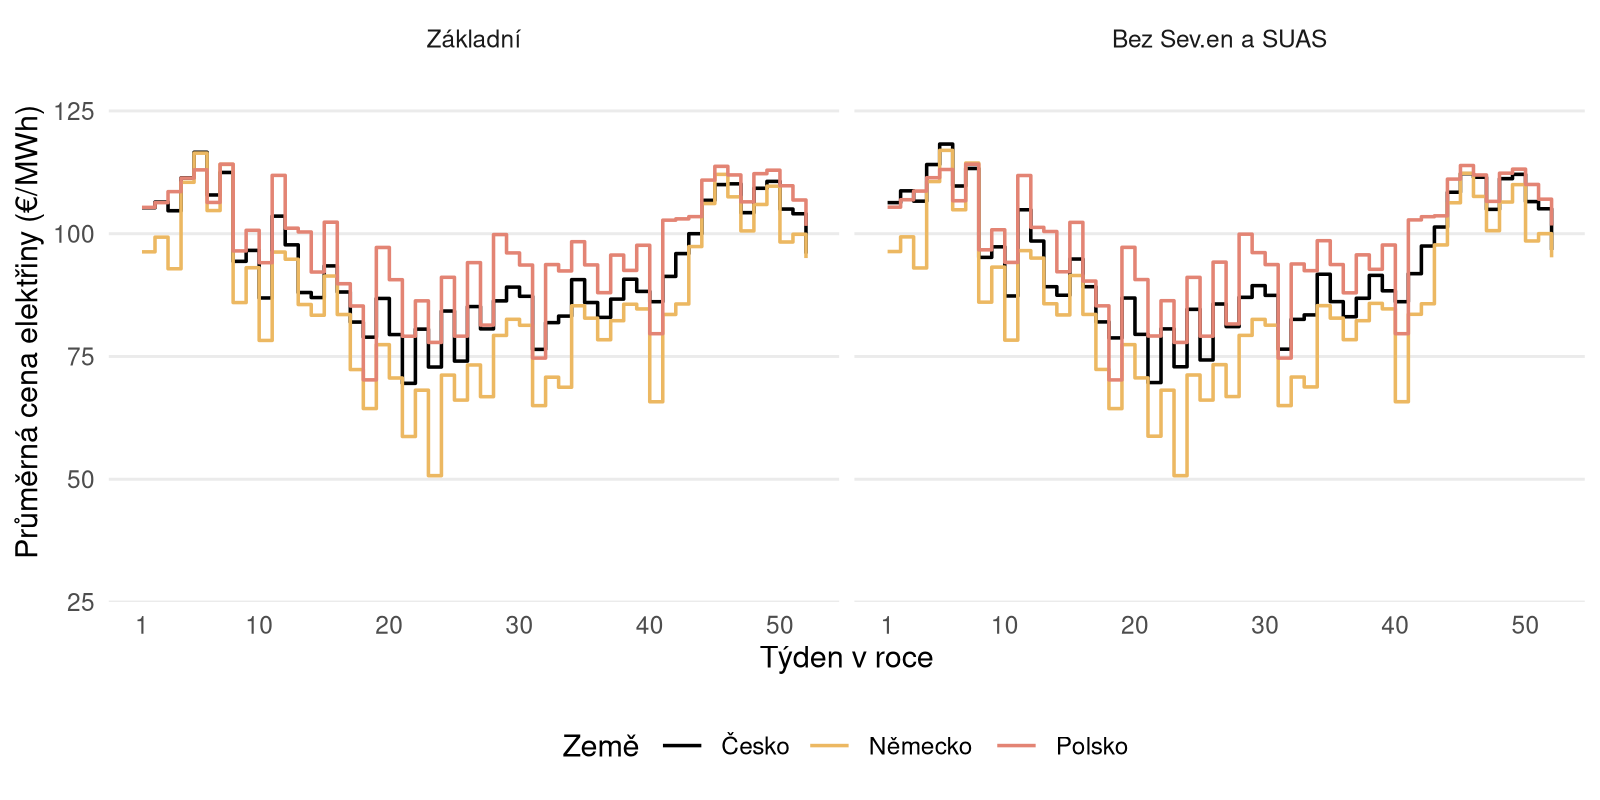

In [30]:
fig_width <- 8
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_weekly_prices <- df_hourlies |>
  select(name, weather, region, Date, Load, Price) |>
  # Select one year
  filter(weather == mainline_weather_year) |>
  group_by(
    name,
    region,
    week = isoweek(Date)
  ) |>
  summarise(
    Demand = sum(Load) / 1e6,
    Price = weighted.mean(Price, Load),
    .groups = "drop"
  )

df_weekly_prices |>
  filter(
    region %in% c("CZ", "DE", "PL"),
    name %in% c("Základní", "Bez Sev.en a SUAS")
  ) |>
  ggplot(aes(week, Price)) +
  geom_step(aes(colour = region), linewidth = .6) +
  scale_x_continuous(
    "Týden v roce",
    breaks = c(1, seq(10, 50, 10))
  ) +
  scale_y_continuous("Průměrná cena elektřiny (€/MWh)") +
  scale_colour_region(name = "Země") +
  facet_grid(cols = vars(name)) +
  coord_cartesian(ylim = c(30, 130)) +
  theme(legend.position = "bottom")

save_svg_data(
  save_svgs,
  df_weekly_prices,
  "fig-4.6-average-weekly-prices",
  fig_width,
  fig_height
)


## Annex: Price duration curves


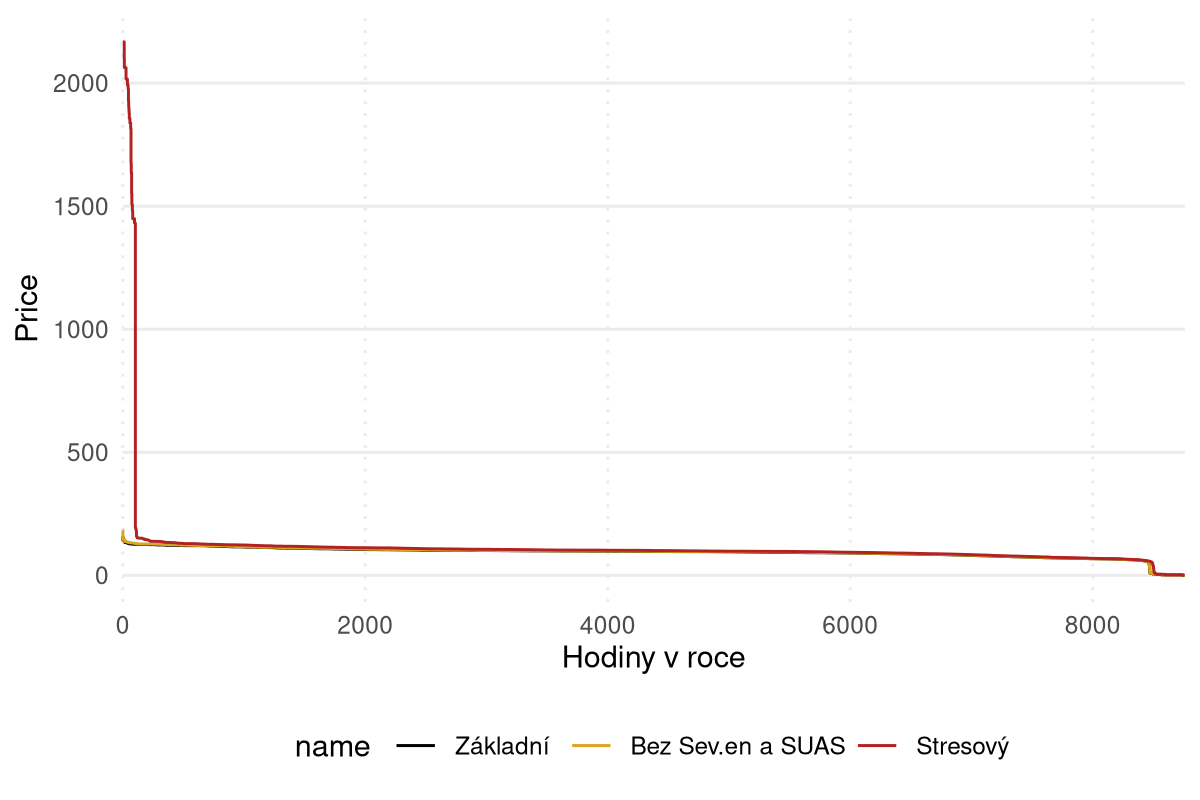

In [31]:
fig_width <- 6
fig_height <- 4
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_hourlies |>
  filter(
    region == "CZ",
    weather == mainline_weather_year,
    name %in% c("Základní", "Bez Sev.en a SUAS", "Stresový")
  ) |>
  ggplot(aes(Price, 8760 * (1 - after_stat(ecdf)))) +
  stat_ecdf(aes(colour = name), pad = FALSE) +
  scale_y_continuous("Hodiny v roce", expand = FALSE) +
  scale_colour_manual(values = c("black", "goldenrod", "firebrick")) +
  coord_flip(clip = "off") +
  theme(
    legend.position = "bottom",
    panel.grid.major.x = element_line(linetype = "dotted")
  )


## Fig. 5.1: Electricity mixes across Europe


In [32]:
df_production_all_countries <- df_all_years_stats |>
  filter(
    stat %in% c("discharging_TWh", "production_TWh"),
    !(source %in% c("TOTAL", "eens", "heat", "li", "pump"))
  ) |>
  summarise(
    val = mean(val),
    .by = c(name, region, source)
  ) |>
  mutate(
    source_group = case_when(
      str_detect(source, "^b_|bio") ~ "Bio",
      str_detect(source, "^coal|^lig") ~ "Coal",
      str_detect(source, "^gas|^oil") ~ "Gas",
      str_detect(source, "^^h_|^pump") ~ "Hydro",
      source == "nuclear" ~ "Nuclear",
      source == "solar" ~ "Solar",
      source %in% c("offshore", "onshore") ~ "Wind",
      .default = "Other"
    ),
  ) |>
  summarise(
    production_TWh = sum(val, na.rm = TRUE),
    .by = c(name, region, source_group)
  ) |>
  bind_rows(
    df_import_totals |>
      filter(stat == "net_import_TWh") |>
      mutate(source_group = "NetImport") |>
      select(name, region, source_group, production_TWh = val)
  ) |>
  arrange(name, region, source_group) |>
  mutate(
    country_name = countrycode::countrycode(
      region,
      origin = "iso2c",
      destination = "cldr.name.cs",
      nomatch = NULL
    )
  )


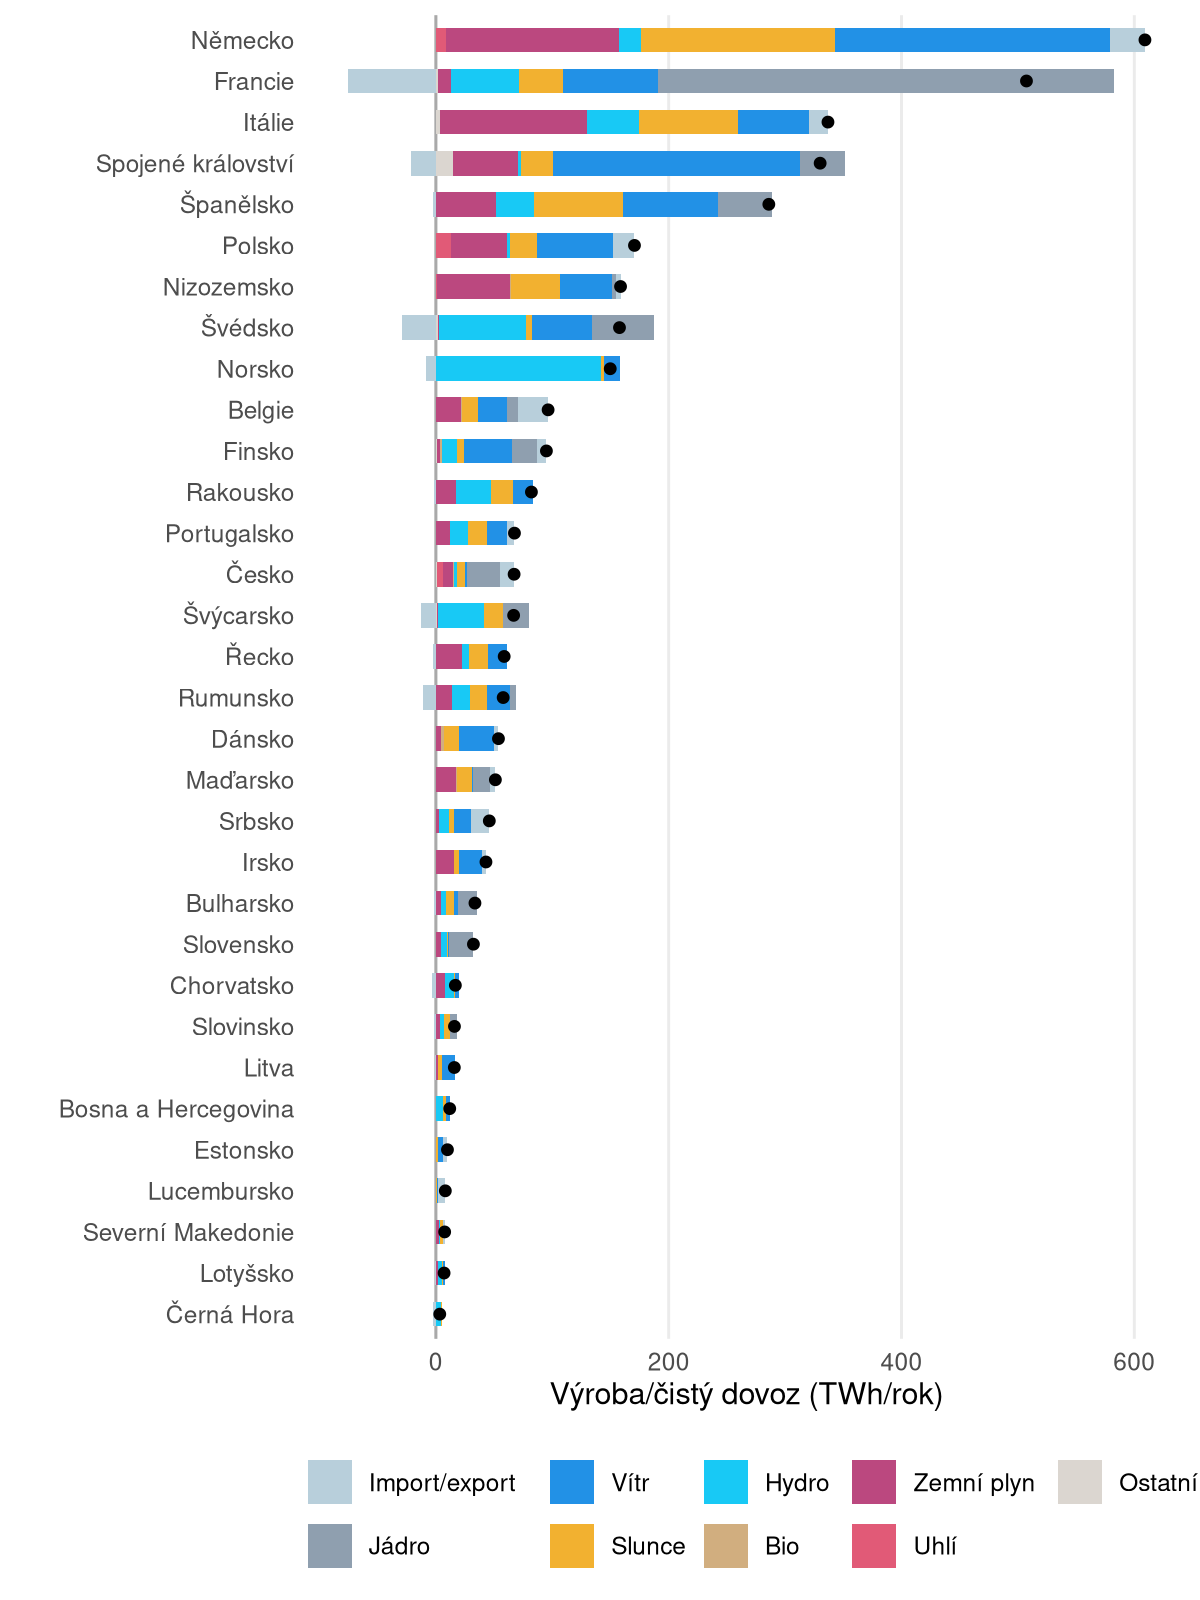

In [33]:
fig_width <- 6
fig_height <- 8
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_production_all_countries |>
  filter(name == "Bez Sev.en a SUAS") |>
  mutate(
    country_name = fct_reorder(country_name, production_TWh, sum)
  ) |>
  ggplot(aes(production_TWh, country_name)) +
  geom_vline(xintercept = 0, colour = "darkgrey") +
  geom_col(
    aes(
      fill = fct_relevel(
        source_group, "NetImport", "Nuclear", "Wind", "Solar", "Hydro", "Bio", "Gas"
      )
    ),
    width = .6
  ) +
  stat_summary(geom = "point", fun = sum, size = 1.5, fill = "black") +
  scale_fill_source() +
  labs(
    x = "Výroba/čistý dovoz (TWh/rok)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(
  save_svgs,
  filter(df_production_all_countries, name == "Bez Sev.en a SUAS"),
  "fig-5.1a-mixes-9-sources-annual",
  fig_width,
  fig_height
)


In [34]:
# Rozdíly mezi základním a stresovým scénářem.

# fig_width <- 8
# fig_height <- 5
# options(repr.plot.width = fig_width, repr.plot.height = fig_height)

# df_production_all_countries |>
#   filter(name %in% c("Základní", "Stresový")) |>
#   mutate(
#     country_name = fct_reorder(country_name, production_TWh, sum)
#   ) |>
#   pivot_wider(names_from = name, values_from = production_TWh) |>
#   transmute(source_group, country_name, Diff = `Stresový` - `Základní`) |>
#   group_by(country_name) |>
#   filter(sum(abs(Diff)) > 2) |>
#   ggplot(aes(Diff, country_name)) +
#   geom_vline(xintercept = 0, colour = "darkgrey") +
#   geom_col(
#     aes(fill = fct_relevel(source_group, "NetImport", "Nuclear", "Renewables", "Gas")),
#     width = .6
#   ) +
#   scale_fill_source() +
#   labs(
#     x = "Výroba/čistý dovoz (TWh/rok)",
#     y = ""
#   ) +
#   theme(
#     legend.position = "bottom",
#     panel.grid.major.y = element_blank(),
#     panel.grid.major.x = element_line()
#   )


## Fig. 5.2: Electricity mixes across Europe during Dunkelflaute


In [48]:
df_production_dunkelflaute <- str_glue("{output_dir}/coaldown2+weather-{dunkelflaute_weather}/2028-ex-seven-suas/*.csv") |>
  Sys.glob() |>
  map(
    ~ read_csv(.x, show_col_types = FALSE) |>
      mutate(
        region = str_extract(.x, "\\w+(?=\\.csv)"),
        .before = 1
      )
  ) |>
  list_rbind() |>
  filter(
    dunkelflaute_period[1] <= Date,
    Date < dunkelflaute_period[2]
  ) |>
  select(region, Date, Load, Solar, Wind, Nuclear, starts_with(c("Charging", "Discharging", "Flexible")), Net_Import) |>
  summarise(across(!Date, ~ sum(.x, na.rm = TRUE)), .by = region) |>
  rowwise() |>
  mutate(
    Batteries = Discharging_li - Charging_li,
    Bio = sum(c_across(matches("^Flexible_(b_|bio)"))),
    Coal = sum(c_across(matches("^Flexible_(coal|lig)"))),
    Gas = sum(c_across(matches("^Flexible_(gas|oil)"))),
    Hydro = sum(c_across(starts_with(c("Discharging_h_", "Discharging_pump")))) -
      sum(c_across(starts_with(c("Charging_h_", "Charging_pump")))),
    NetImport = Net_Import,
    Nuclear,
    Other = Batteries + Flexible_dsr + Flexible_waste,
    Solar,
    Wind,
    .keep = "unused"
  ) |>
  select(!c(Batteries, Charging, Discharging, Flexible, Flexible_eens)) |>
  ungroup() |>
  mutate(
    country_name = countrycode::countrycode(
      region,
      origin = "iso2c",
      destination = "cldr.name.cs",
      nomatch = NULL
    ),
    .after = region
  )


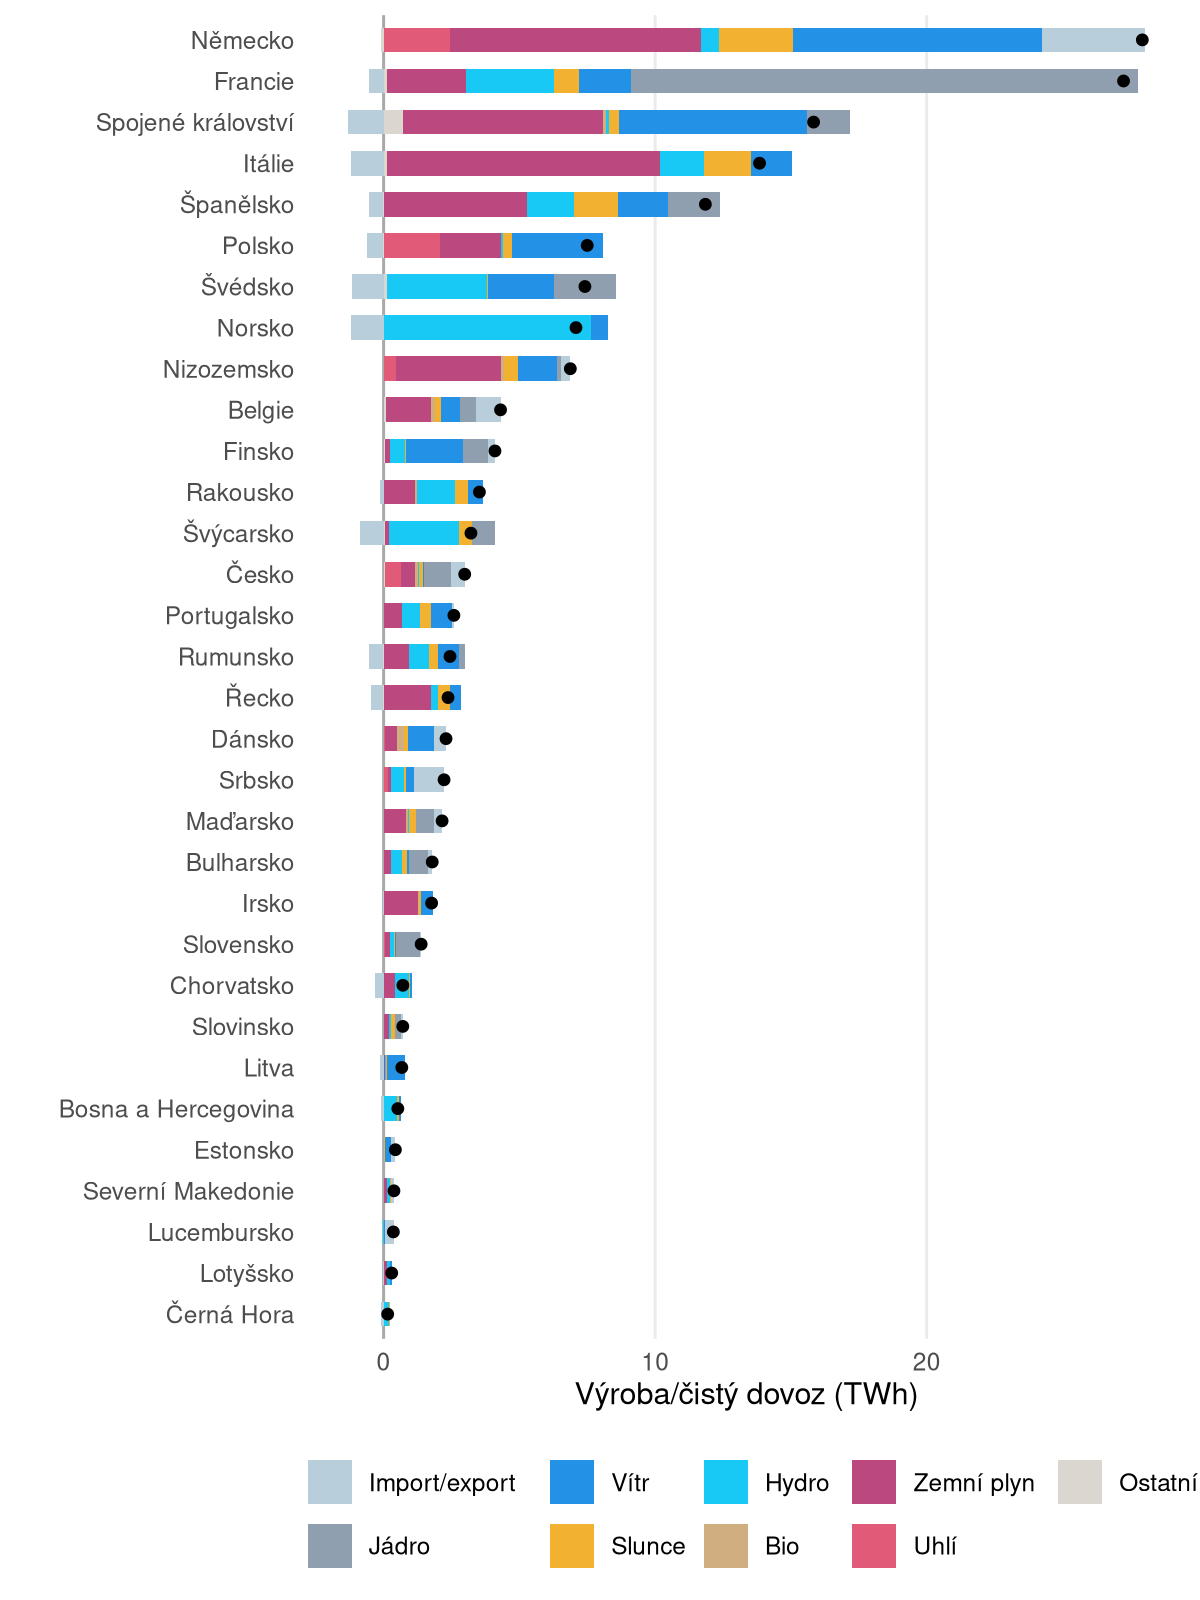

In [ ]:
fig_width <- 6
fig_height <- 8
options(repr.plot.width = fig_width, repr.plot.height = fig_height)

df_production_dunkelflaute |>
  select(!Load) |>
  pivot_longer(!region:country_name, names_to = "source_group", values_to = "production_MWh") |>
  mutate(
    country_name = fct_reorder(country_name, production_MWh, sum)
  ) |>
  ggplot(aes(production_MWh / 1e6, country_name)) +
  geom_vline(xintercept = 0, colour = "darkgrey") +
  geom_col(
    aes(
      fill = fct_relevel(
        source_group, "NetImport", "Nuclear", "Wind", "Solar", "Hydro", "Bio", "Gas"
      )
    ),
    width = .6
  ) +
  geom_point(
    aes(x = Load / 1e6),
    data = df_production_dunkelflaute,
    size = 1.5,
    fill = "black"
  ) +
  scale_fill_source() +
  labs(
    x = "Výroba/čistý dovoz (TWh)",
    y = ""
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line()
  )

save_svg_data(
  save_svgs,
  filter(df_production_all_countries, name == "Bez Sev.en a SUAS"),
  "fig-5.2a-mixes-9-sources-dunkelflaute",
  fig_width,
  fig_height
)


## Annex: Peak load periods


In [37]:
df_load_all_years <- str_glue("{output_dir}/coaldown2+weather-WS??/2028-base/CZ.csv") |>
  Sys.glob() |>
  map(
    ~ read_csv(.x) |>
      select(Date, Load) |>
      mutate(
        name = str_extract(.x, "(?<=/)[^/]+(?=/\\w+\\.csv)"),
        weather = str_extract(.x, "WS\\d\\d"),
        .before = 1
      )
  ) |>
  list_rbind() |>
  fix_scenario_names()


In [38]:
# TODO: What is the available dispatchable capacity
# in the scenarios?
peak_load_threshold_mw <- 10000

df_peaks <- df_load_all_years |>
  filter(name == "Základní") |>
  mutate(PeakLoad = Load >= peak_load_threshold_mw) |>
  filter(PeakLoad) |>
  group_by(weather) |>
  mutate(
    DateDiff = c(1, diff(Date)),
    Group = cumsum(DateDiff > 1)
  ) |>
  group_by(Group, .add = TRUE) |>
  summarise(
    StartDate = min(Date),
    NumHours = n(),
    ExtraGWh = sum(Load - peak_load_threshold_mw) / 1000,
    MaxLoadMW = max(Load),
    .groups = "drop"
  )

df_peaks |> slice_max(NumHours, n = 10)


weather,Group,StartDate,NumHours,ExtraGWh,MaxLoadMW
<chr>,<int>,<dttm>,<int>,<dbl>,<dbl>
WS01,39,2018-02-26 05:00:00,15,12.185788,11251.86
WS01,40,2018-02-27 05:00:00,15,12.988517,11317.73
WS01,41,2018-02-28 05:00:00,15,13.869442,11440.02
WS01,42,2018-03-01 05:00:00,15,11.912360,11203.81
WS04,10,2018-01-31 05:00:00,15,13.635729,11336.07
WS01,43,2018-03-02 05:00:00,14,9.093923,11255.18
WS04,15,2018-02-07 05:00:00,14,6.892206,10851.17
WS13,13,2018-01-24 06:00:00,14,8.807293,10831.42
WS13,14,2018-01-25 05:00:00,14,10.857272,11119.33
